<a href="https://colab.research.google.com/github/Malek720/MachineLearning/blob/%C3%89quit%C3%A9-Salariale/Module1_Equite_Salariale_complet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Détecteur d'Équité Salariale et d'Injustice
**Gender & Diversity Pay Gap** · Classification supervisée · Dataset : *Adult (Census Income)*

| Étape | Contenu |
|---|---|
| **1** | Chargement (upload à l'exécution) + analyse exploratoire des problèmes de qualité |
| **2** | Nettoyage approfondi (colonnes redondantes, valeurs manquantes, valeurs aberrantes, target) + justifications + avant/après |
| **3** | Matrice de sélection des features (4 à 5 maximum) |
| **4** | Transformation des données (split, encodage, normalisation) |
| **5** | Segmentation (K-Means) : profils de collaborateurs et écarts par segment |
| **6** | Classification supervisée de la target d'équité (4 modèles, réglage, seuil) |
| **7** | Évaluation, interprétation, audit d'équité et limites |

> Toutes les figures et tableaux importants sont **sauvegardés automatiquement en PNG** dans le dossier `captures/` (un zip est généré à la fin) pour la présentation.

## Configuration

In [ ]:
import os, io, re, textwrap, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold"})
RANDOM_STATE = 42

CAP = "captures"
os.makedirs(CAP, exist_ok=True)

def save_fig(name):
    """Sauvegarde la figure courante en PNG (pour la présentation) puis l'affiche."""
    path = f"{CAP}/{name}.png"
    plt.savefig(path, dpi=160, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"📸 capture enregistrée : {path}")

def save_table(df, name, title=None, index=False, wrap=38, fs=9):
    """Rend un DataFrame sous forme d'image propre (idéal pour une slide)."""
    d = df.reset_index() if index else df.copy()
    fmt = lambda v: f"{v:,.3f}" if isinstance(v, (float, np.floating)) else str(v)
    d = d.astype(object).apply(lambda col: col.map(fmt))
    d = d.apply(lambda col: col.map(lambda s: textwrap.fill(s, wrap)))
    cols = [textwrap.fill(str(c), wrap) for c in d.columns]
    lines = [max(s.count("\n") + 1 for s in row) for row in d.values]
    longest = lambda txt: max(len(x) for x in str(txt).split("\n"))
    lens = [max([longest(s) for s in d[c]] + [longest(h)]) + 2 for c, h in zip(d.columns, cols)]
    W = max(6, min(22, 0.11 * sum(lens) + 0.3 * len(lens)))
    unit, top = 0.30, 0.7
    H = top + unit * (sum(lines) + 1.4)
    fig = plt.figure(figsize=(W, H))
    ax = fig.add_axes([0, 0, 1, 1 - top / H]); ax.axis("off")
    if title:
        fig.text(0.5, 1 - 0.35 / H, title, ha="center", va="center", fontsize=13, fontweight="bold")
    t = ax.table(cellText=d.values, colLabels=cols, colWidths=[l / sum(lens) for l in lens],
                 loc="upper center", cellLoc="center")
    t.auto_set_font_size(False); t.set_fontsize(fs)
    row_lines = [1.4] + lines
    for (r, c), cell in t.get_celld().items():
        cell.set_height(unit * row_lines[r] / (H - top))
        cell.set_edgecolor("#C9D3DF")
        if r == 0:
            cell.set_facecolor("#1F4E79"); cell.set_text_props(color="white", weight="bold")
        elif r % 2 == 0:
            cell.set_facecolor("#EAF1F8")
    save_fig(name)

def cramers_v(x, y):
    """V de Cramér (corrigé du biais) entre deux variables catégorielles. Valeur dans [0, 1]."""
    ct = pd.crosstab(x, y)
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return 0.0
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum(); r, k = ct.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    d = min(kc - 1, rc - 1)
    return float(np.sqrt(phi2 / d)) if d > 0 else 0.0

print("✔ configuration prête")

✔ configuration prête


---
# ÉTAPE 1 — Chargement des données et analyse des problèmes

## 1.1 Upload du fichier à l'exécution
Dans **Google Colab**, une fenêtre s'ouvre : sélectionne le fichier `adult.data`.
En local (Jupyter), le fichier `adult.data` doit se trouver dans le même dossier que le notebook.

📂 Sélectionne le fichier adult.data ...


Saving adult.data to adult.data
✔ Fichier chargé : 32,561 lignes × 15 colonnes


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


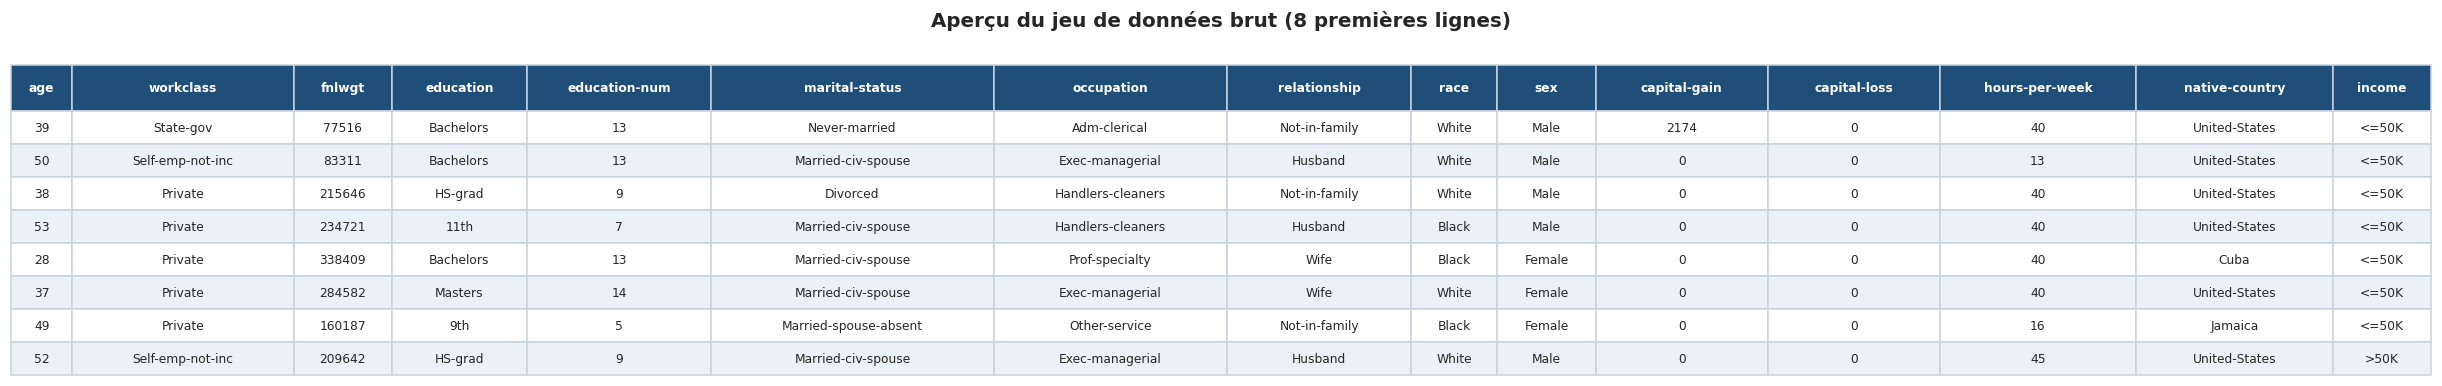

📸 capture enregistrée : captures/01_apercu_donnees.png


In [ ]:
COLS = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
        "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
        "hours-per-week", "native-country", "income"]

try:                                    # --- Google Colab : upload interactif
    from google.colab import files
    print("📂 Sélectionne le fichier adult.data ...")
    _uploaded = files.upload()
    DATA_PATH = next(iter(_uploaded))
except ImportError:                     # --- Jupyter local
    DATA_PATH = "adult.data"
    print(f"Mode local : lecture de '{DATA_PATH}'")

# Le fichier brut n'a PAS d'en-tête et sépare les champs par ", " -> skipinitialspace
df_raw = pd.read_csv(DATA_PATH, header=None, names=COLS, skipinitialspace=True)
print(f"✔ Fichier chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
display(df_raw.head())
save_table(df_raw.head(8), "01_apercu_donnees", title="Aperçu du jeu de données brut (8 premières lignes)", fs=8)

## 1.2 Structure : types, cardinalité, valeurs manquantes

,Type,Valeurs distinctes,NaN (pandas),Exemple
age,int64,73,0,39
workclass,str,9,0,State-gov
fnlwgt,int64,21648,0,77516
education,str,16,0,Bachelors
education-num,int64,16,0,13
marital-status,str,7,0,Never-married
occupation,str,15,0,Adm-clerical
relationship,str,6,0,Not-in-family
race,str,5,0,White
sex,str,2,0,Male


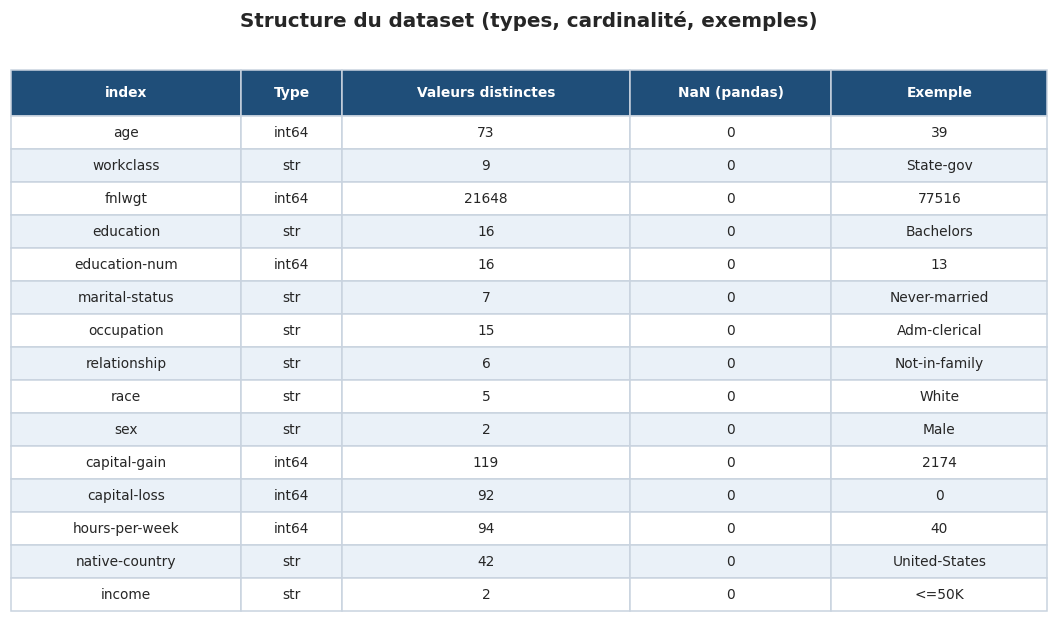

📸 capture enregistrée : captures/02_structure_colonnes.png


In [ ]:
structure = pd.DataFrame({
    "Type": df_raw.dtypes.astype(str),
    "Valeurs distinctes": df_raw.nunique(),
    "NaN (pandas)": df_raw.isna().sum(),
    "Exemple": df_raw.iloc[0].astype(str),
})
display(structure)
save_table(structure, "02_structure_colonnes", title="Structure du dataset (types, cardinalité, exemples)", index=True)

### Dictionnaire des données
Description de chaque variable du fichier `adult.data` et **rôle qu'elle joue dans le Module 1** (feature candidate, attribut sensible réservé à l'audit, variable supprimée ou cible).

,Variable,Type,Description,Rôle dans le Module 1
0,age,Numérique,Âge en années (plafonné à 90 par le recensement),Feature candidate
1,workclass,Catégorielle,"Type d'employeur (privé, public, indépendant...)",Feature candidate
2,fnlwgt,Numérique,Poids d'échantillonnage du recensement US,Supprimée (non pertinente)
3,education,Catégorielle,"Niveau d'études en texte (Bachelors, HS-grad...)",Supprimée (doublon de education-num)
4,education-num,Numérique ordinale,Niveau d'études codé de 1 à 16,Feature candidate
5,marital-status,Catégorielle,Situation familiale,Sensible : audit uniquement
6,occupation,Catégorielle,Métier / poste occupé,Feature candidate
7,relationship,Catégorielle,"Rôle dans le foyer (Husband, Wife...)","Supprimée (redondante, révèle le genre)"
8,race,Catégorielle,Origine déclarée,Sensible : audit uniquement
9,sex,Catégorielle,Genre (Male / Female),Sensible : audit uniquement


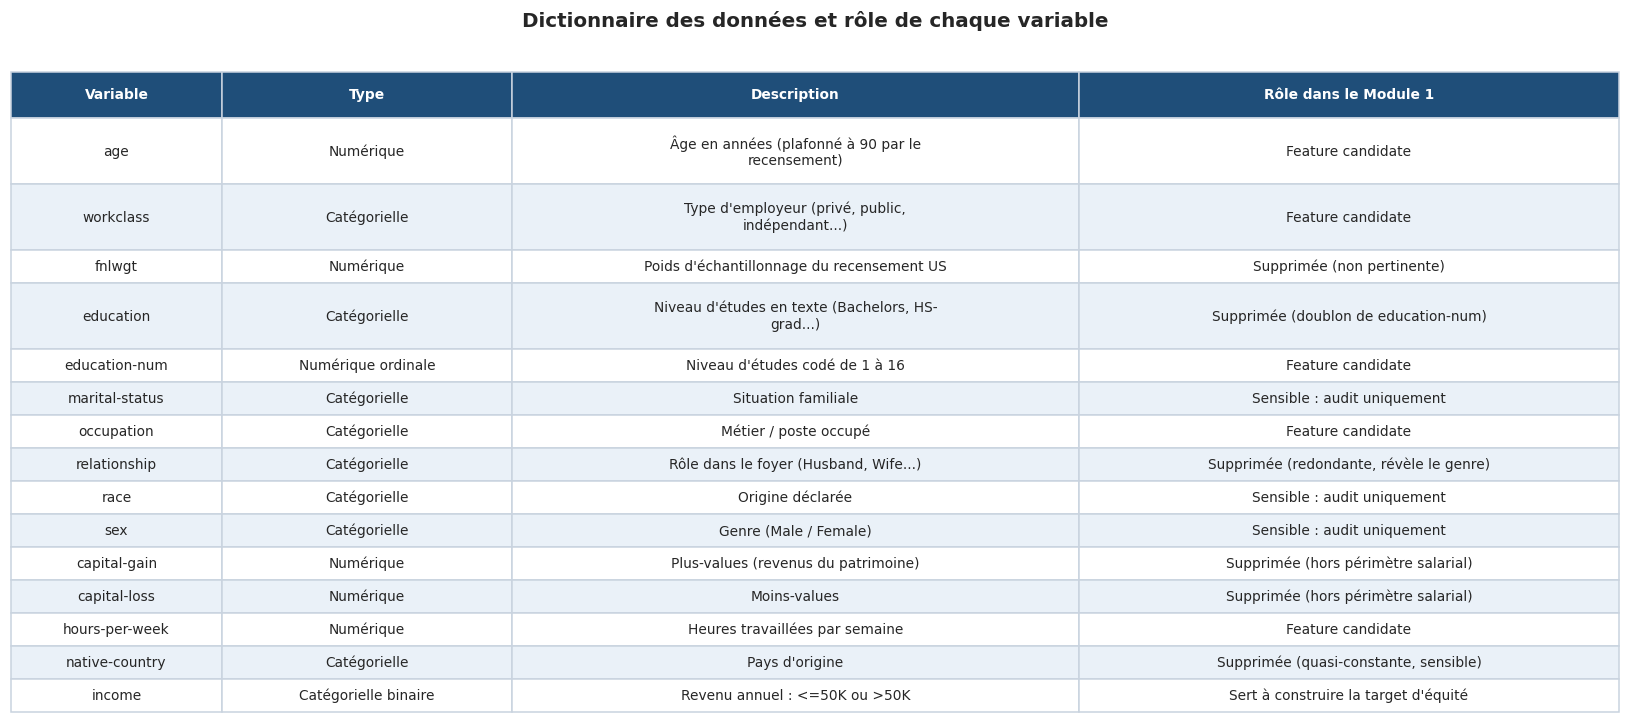

📸 capture enregistrée : captures/01b_dictionnaire_donnees.png


In [ ]:
dico = pd.DataFrame([
    ["age", "Numérique", "Âge en années (plafonné à 90 par le recensement)", "Feature candidate"],
    ["workclass", "Catégorielle", "Type d'employeur (privé, public, indépendant...)", "Feature candidate"],
    ["fnlwgt", "Numérique", "Poids d'échantillonnage du recensement US", "Supprimée (non pertinente)"],
    ["education", "Catégorielle", "Niveau d'études en texte (Bachelors, HS-grad...)", "Supprimée (doublon de education-num)"],
    ["education-num", "Numérique ordinale", "Niveau d'études codé de 1 à 16", "Feature candidate"],
    ["marital-status", "Catégorielle", "Situation familiale", "Sensible : audit uniquement"],
    ["occupation", "Catégorielle", "Métier / poste occupé", "Feature candidate"],
    ["relationship", "Catégorielle", "Rôle dans le foyer (Husband, Wife...)", "Supprimée (redondante, révèle le genre)"],
    ["race", "Catégorielle", "Origine déclarée", "Sensible : audit uniquement"],
    ["sex", "Catégorielle", "Genre (Male / Female)", "Sensible : audit uniquement"],
    ["capital-gain", "Numérique", "Plus-values (revenus du patrimoine)", "Supprimée (hors périmètre salarial)"],
    ["capital-loss", "Numérique", "Moins-values", "Supprimée (hors périmètre salarial)"],
    ["hours-per-week", "Numérique", "Heures travaillées par semaine", "Feature candidate"],
    ["native-country", "Catégorielle", "Pays d'origine", "Supprimée (quasi-constante, sensible)"],
    ["income", "Catégorielle binaire", "Revenu annuel : <=50K ou >50K", "Sert à construire la target d'équité"],
], columns=["Variable", "Type", "Description", "Rôle dans le Module 1"])
display(dico)
save_table(dico, "01b_dictionnaire_donnees", title="Dictionnaire des données et rôle de chaque variable", wrap=44, fs=9)

## 1.3 Problème n°1 — Valeurs manquantes *cachées* (`?`)
`isna()` annonce **0 valeur manquante**, mais le dataset code l'absence d'information par le caractère `?`.

,NaN détectés par pandas,'?' cachés,% de lignes concernées
workclass,0,1836,5.64
occupation,0,1843,5.66
native-country,0,583,1.79


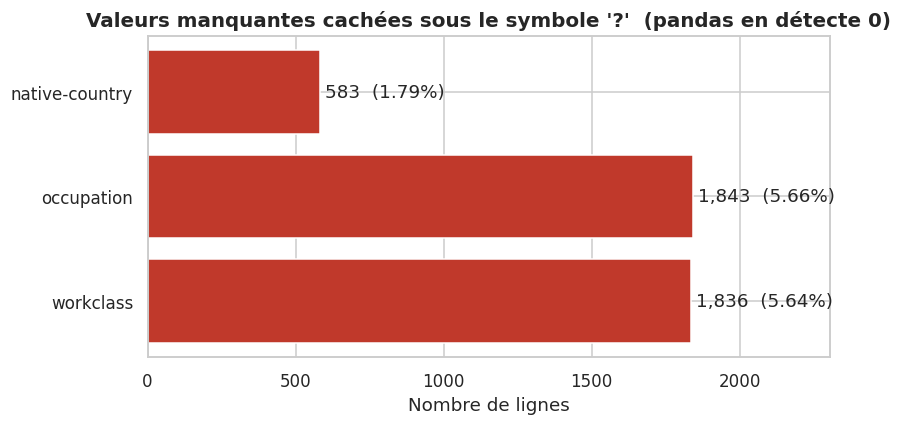

📸 capture enregistrée : captures/03_valeurs_manquantes_cachees.png
→ 1,836 lignes ont workclass ET occupation manquants en même temps (même profil de non-réponse).


In [ ]:
q_count = (df_raw == "?").sum()
miss = pd.DataFrame({"NaN détectés par pandas": df_raw.isna().sum(),
                     "'?' cachés": q_count,
                     "% de lignes concernées": (q_count / len(df_raw) * 100).round(2)})
miss = miss[miss["'?' cachés"] > 0]
display(miss)

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(miss.index, miss["'?' cachés"], color="#C0392B")
for b, p in zip(bars, miss["% de lignes concernées"]):
    ax.text(b.get_width() + 15, b.get_y() + b.get_height() / 2, f"{b.get_width():,.0f}  ({p}%)", va="center")
ax.set_title("Valeurs manquantes cachées sous le symbole '?'  (pandas en détecte 0)")
ax.set_xlabel("Nombre de lignes"); ax.set_xlim(0, miss["'?' cachés"].max() * 1.25)
save_fig("03_valeurs_manquantes_cachees")

both = ((df_raw["workclass"] == "?") & (df_raw["occupation"] == "?")).sum()
print(f"→ {both:,} lignes ont workclass ET occupation manquants en même temps (même profil de non-réponse).")

## 1.4 Problème n°2 — Doublons

Lignes dupliquées (copies en trop) : 24  (0.074 %)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
15189,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
21490,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K


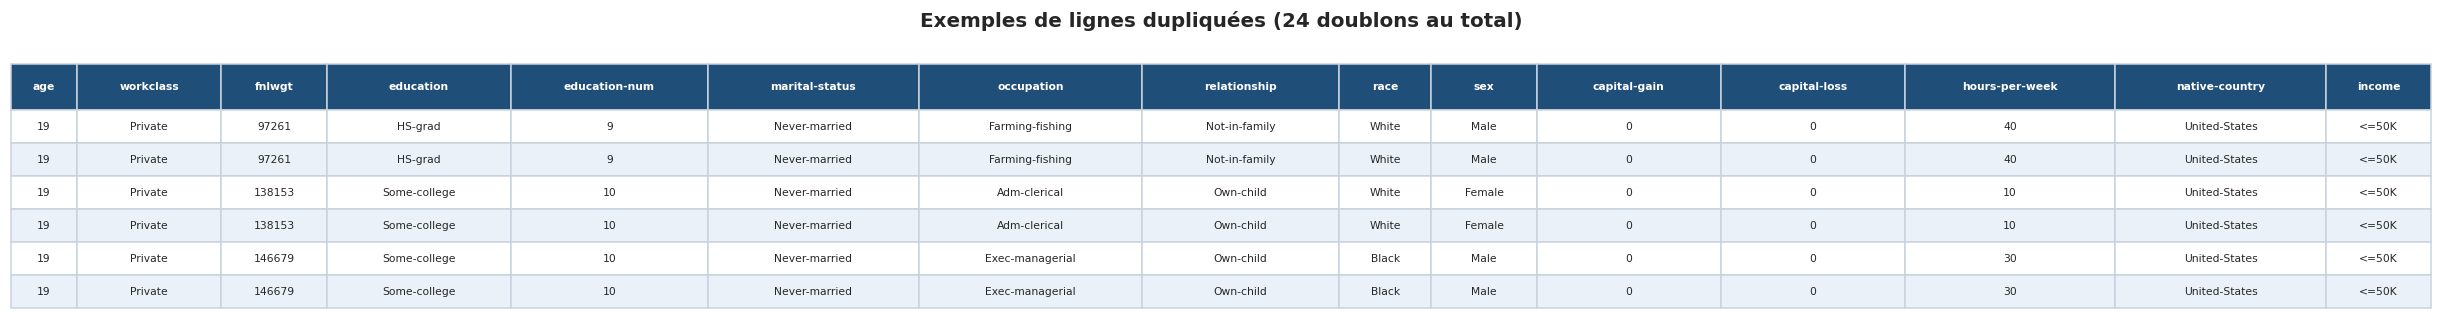

📸 capture enregistrée : captures/04_doublons_exemples.png


In [ ]:
dup_mask = df_raw.duplicated(keep=False)
n_dup = df_raw.duplicated().sum()
print(f"Lignes dupliquées (copies en trop) : {n_dup}  ({n_dup/len(df_raw)*100:.3f} %)")
display(df_raw[dup_mask].sort_values(COLS).head(6))
save_table(df_raw[dup_mask].sort_values(COLS).head(6), "04_doublons_exemples",
           title=f"Exemples de lignes dupliquées ({n_dup} doublons au total)", fs=7)

## 1.5 Problème n°3 — Valeurs aberrantes et distributions suspectes

,min,médiane,max,% zéros,outliers IQR (nb),outliers IQR (%)
age,17.0,37.0,90.0,0.00,143.0,0.44
fnlwgt,12285.0,178356.0,1484705.0,0.00,992.0,3.05
education-num,1.0,10.0,16.0,0.00,1198.0,3.68
capital-gain,0.0,0.0,99999.0,91.67,2712.0,8.33
capital-loss,0.0,0.0,4356.0,95.33,1519.0,4.67
hours-per-week,1.0,40.0,99.0,0.00,9008.0,27.66


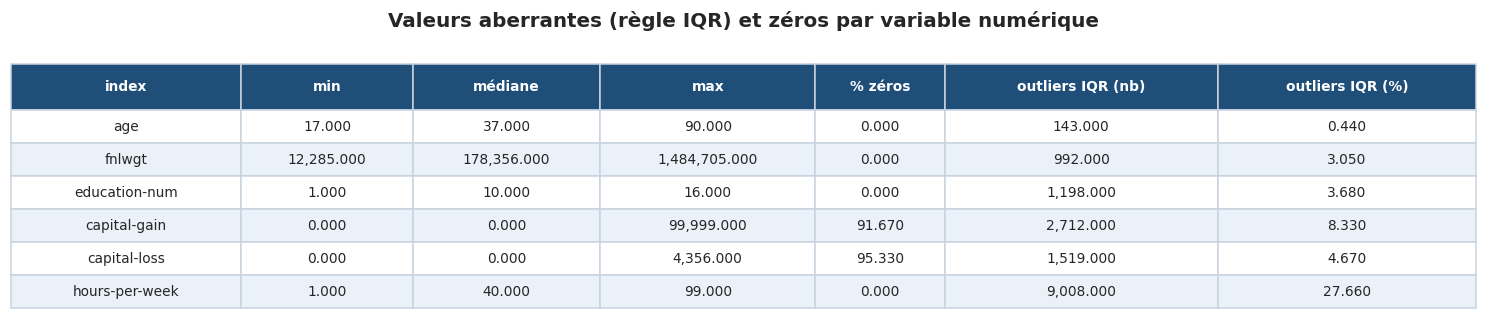

📸 capture enregistrée : captures/05_tableau_outliers.png


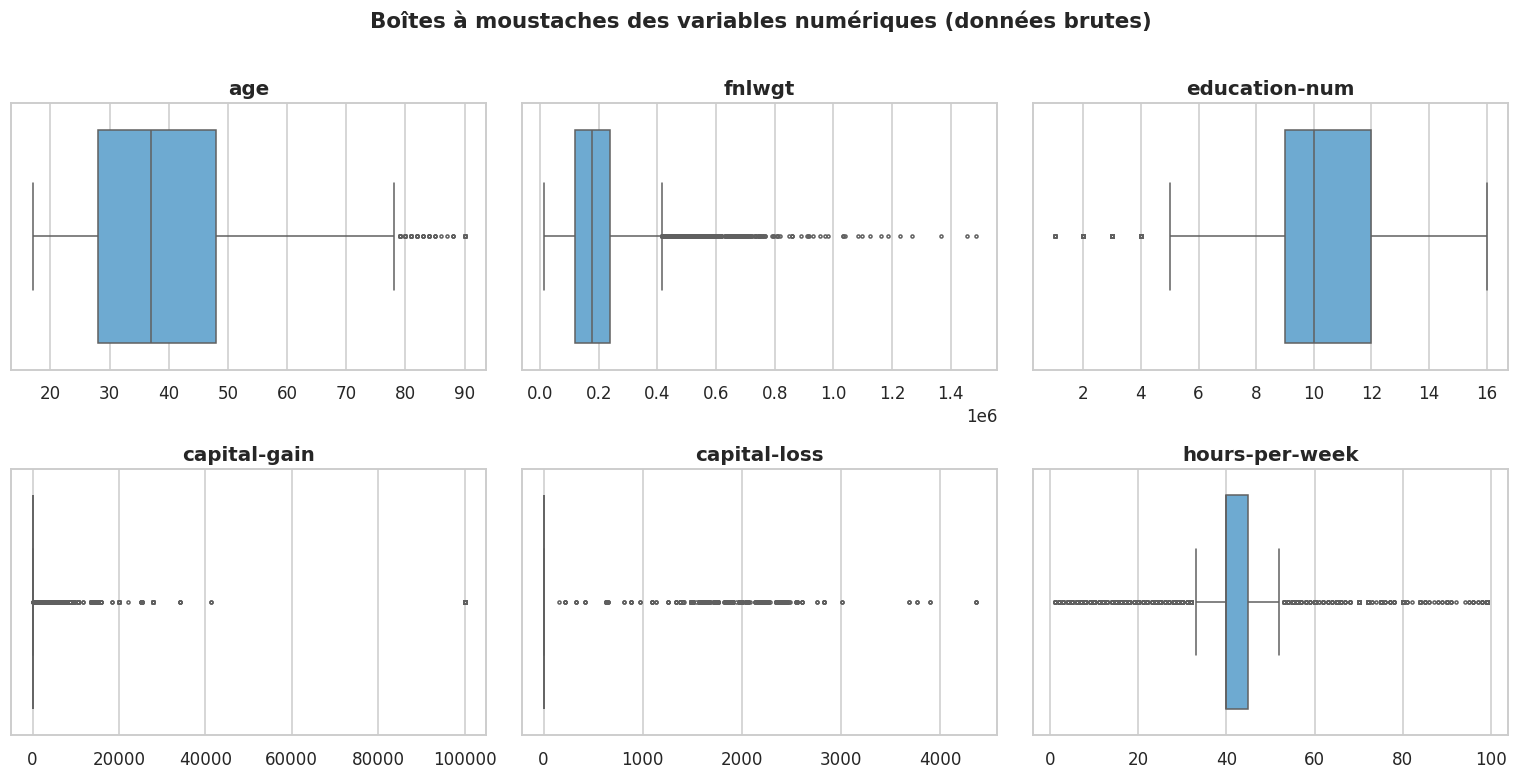

📸 capture enregistrée : captures/06_boxplots_brut.png
capital-gain = 99999 : 159 lignes → valeur plafond/code (top-coding), pas un vrai montant.
capital-gain = 0 : 91.7 %  |  capital-loss = 0 : 95.3 %
hours-per-week > 80 : 208 lignes  |  hours-per-week < 5 : 145 lignes
age = 90 (plafond du recensement) : 43 lignes


In [ ]:
num_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

def iqr_stats(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    lo, hi = q1 - 1.5 * i, q3 + 1.5 * i
    return pd.Series({"min": s.min(), "médiane": s.median(), "max": s.max(),
                      "% zéros": (s == 0).mean() * 100,
                      "outliers IQR (nb)": int(((s < lo) | (s > hi)).sum()),
                      "outliers IQR (%)": ((s < lo) | (s > hi)).mean() * 100})
outl = df_raw[num_cols].apply(iqr_stats).T.round(2)
display(outl)
save_table(outl, "05_tableau_outliers", title="Valeurs aberrantes (règle IQR) et zéros par variable numérique", index=True)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), num_cols):
    sns.boxplot(x=df_raw[c], ax=ax, color="#5DADE2", fliersize=2)
    ax.set_title(c); ax.set_xlabel("")
fig.suptitle("Boîtes à moustaches des variables numériques (données brutes)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); save_fig("06_boxplots_brut")

n99 = (df_raw["capital-gain"] == 99999).sum()
print(f"capital-gain = 99999 : {n99} lignes → valeur plafond/code (top-coding), pas un vrai montant.")
print(f"capital-gain = 0 : {(df_raw['capital-gain']==0).mean()*100:.1f} %  |  capital-loss = 0 : {(df_raw['capital-loss']==0).mean()*100:.1f} %")
print(f"hours-per-week > 80 : {(df_raw['hours-per-week']>80).sum()} lignes  |  hours-per-week < 5 : {(df_raw['hours-per-week']<5).sum()} lignes")
print(f"age = 90 (plafond du recensement) : {(df_raw['age']==90).sum()} lignes")

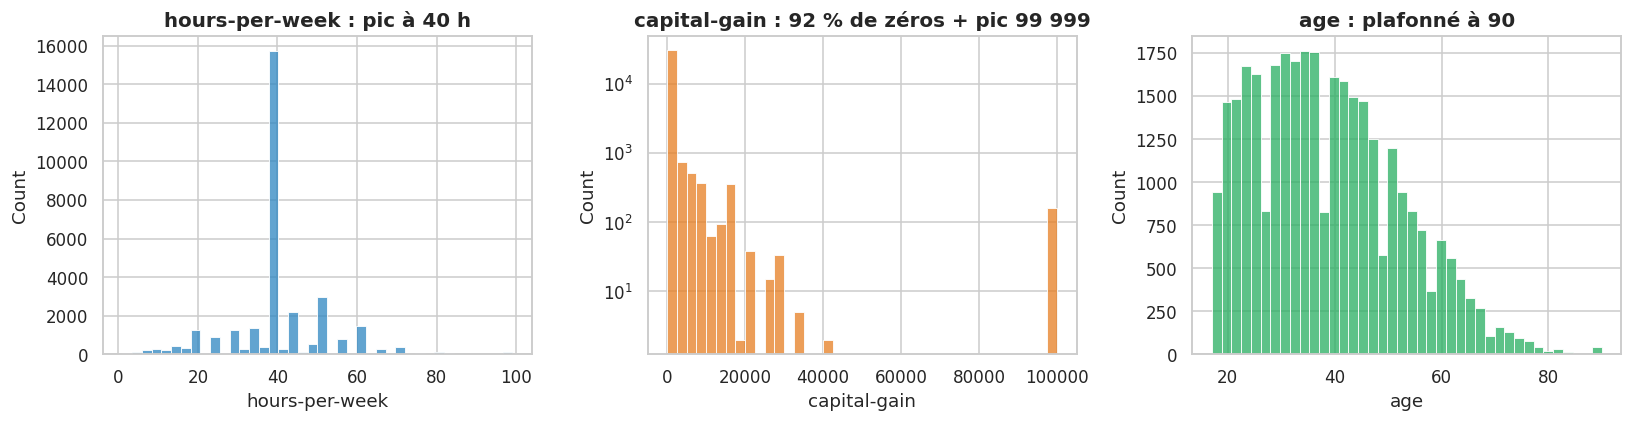

📸 capture enregistrée : captures/07_distributions_suspectes.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_raw["hours-per-week"], bins=40, ax=axes[0], color="#2E86C1"); axes[0].set_title("hours-per-week : pic à 40 h")
sns.histplot(df_raw["capital-gain"], bins=40, ax=axes[1], color="#E67E22"); axes[1].set_title("capital-gain : 92 % de zéros + pic 99 999"); axes[1].set_yscale("log")
sns.histplot(df_raw["age"], bins=40, ax=axes[2], color="#27AE60"); axes[2].set_title("age : plafonné à 90")
plt.tight_layout(); save_fig("07_distributions_suspectes")

## 1.6 Problème n°4 — Colonnes redondantes
Deux outils : la **corrélation** entre variables numériques et le **V de Cramér** (0 = indépendantes, 1 = information identique) entre variables catégorielles.

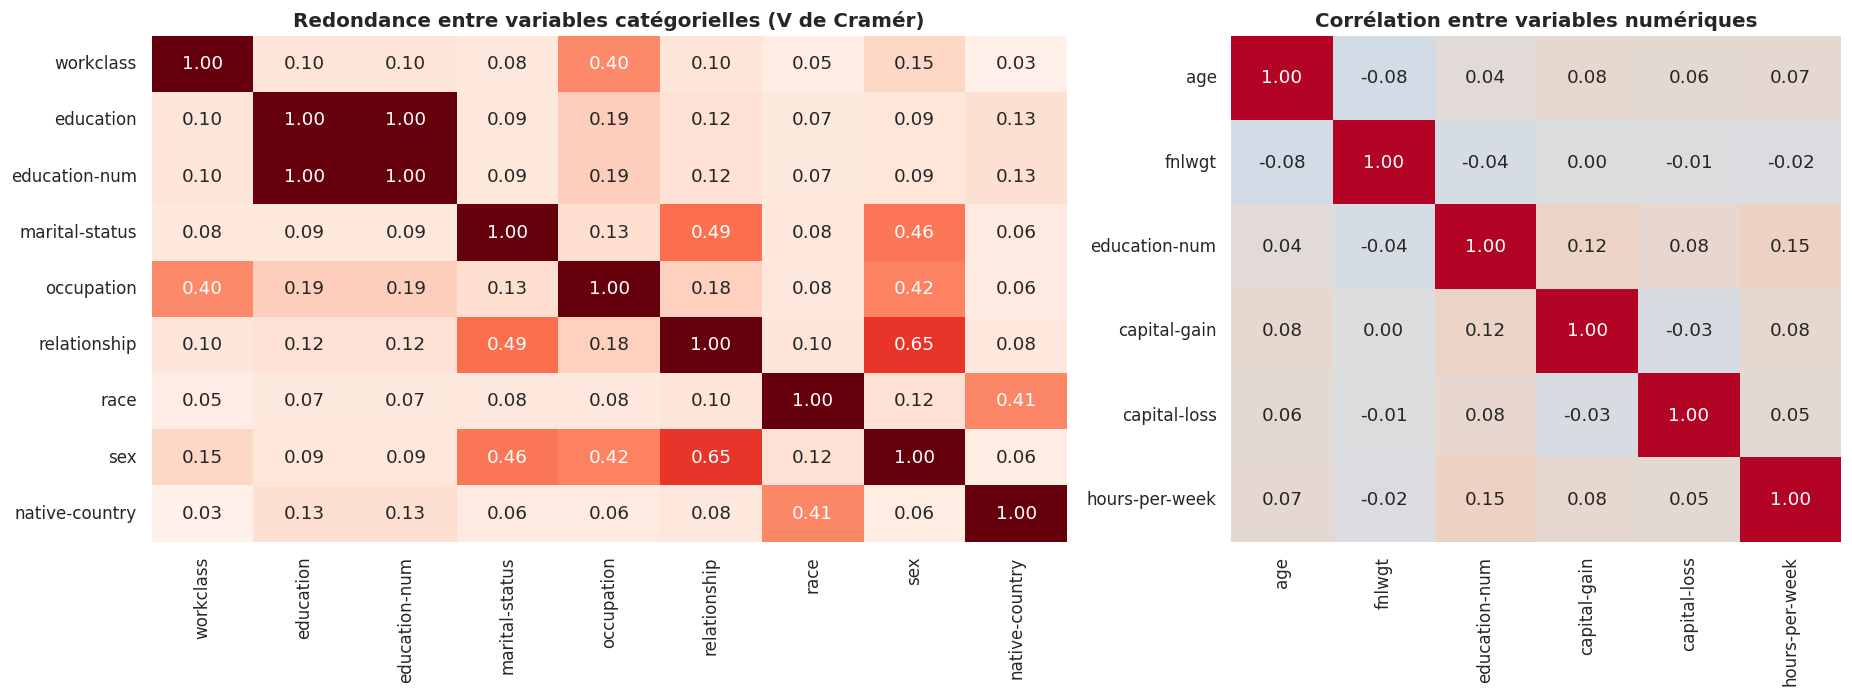

📸 capture enregistrée : captures/08_redondance_variables.png
education → education-num : 1 valeur(s) par modalité ; education-num → education : 1 → correspondance 1-pour-1 : True
V(relationship, sex) = 0.65  |  V(relationship, marital-status) = 0.49


In [ ]:
cat_for_v = ["workclass", "education", "education-num", "marital-status", "occupation",
             "relationship", "race", "sex", "native-country"]
V = pd.DataFrame(index=cat_for_v, columns=cat_for_v, dtype=float)
for a in cat_for_v:
    for b in cat_for_v:
        V.loc[a, b] = 1.0 if a == b else cramers_v(df_raw[a], df_raw[b])

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={"width_ratios": [1.5, 1]})
sns.heatmap(V, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Redondance entre variables catégorielles (V de Cramér)")
sns.heatmap(df_raw[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1], cbar=False)
axes[1].set_title("Corrélation entre variables numériques")
plt.tight_layout(); save_fig("08_redondance_variables")

# preuve : education <-> education-num est une correspondance 1-pour-1
a = df_raw.groupby("education")["education-num"].nunique().max()
b = df_raw.groupby("education-num")["education"].nunique().max()
print(f"education → education-num : {a} valeur(s) par modalité ; education-num → education : {b} → correspondance 1-pour-1 : {a==1 and b==1}")
print(f"V(relationship, sex) = {V.loc['relationship','sex']:.2f}  |  V(relationship, marital-status) = {V.loc['relationship','marital-status']:.2f}")

## 1.7 Problème n°5 — Colonnes quasi-constantes (peu informatives)

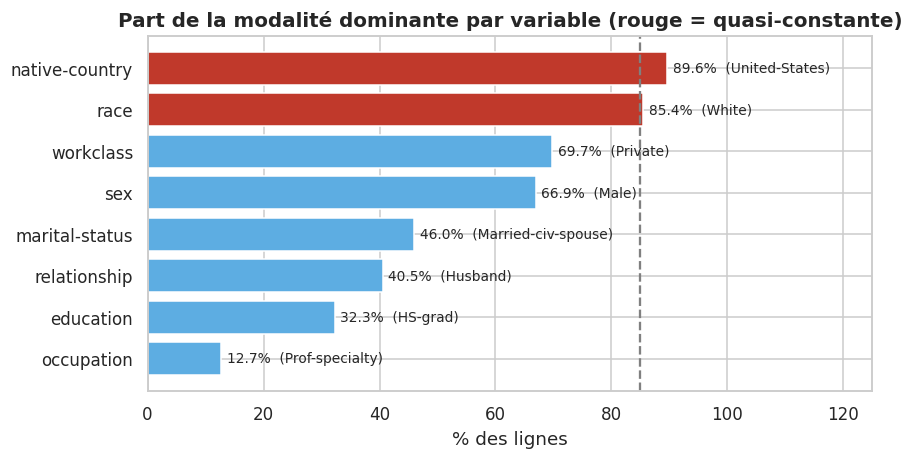

📸 capture enregistrée : captures/09_variables_quasi_constantes.png


In [ ]:
cat_cols = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]
top_share = pd.Series({c: df_raw[c].value_counts(normalize=True).iloc[0] * 100 for c in cat_cols}).sort_values()
top_label = {c: df_raw[c].value_counts().index[0] for c in cat_cols}

fig, ax = plt.subplots(figsize=(8.5, 4.2))
colors = ["#C0392B" if v > 85 else "#5DADE2" for v in top_share]
bars = ax.barh(top_share.index, top_share.values, color=colors)
for b_, c in zip(bars, top_share.index):
    ax.text(b_.get_width() + 1, b_.get_y() + b_.get_height() / 2, f"{b_.get_width():.1f}%  ({top_label[c]})", va="center", fontsize=9)
ax.axvline(85, ls="--", color="grey"); ax.set_xlim(0, 125)
ax.set_title("Part de la modalité dominante par variable (rouge = quasi-constante)")
ax.set_xlabel("% des lignes")
save_fig("09_variables_quasi_constantes")

## 1.8 La variable cible `income` : labels et déséquilibre

Labels bruts de income : <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str


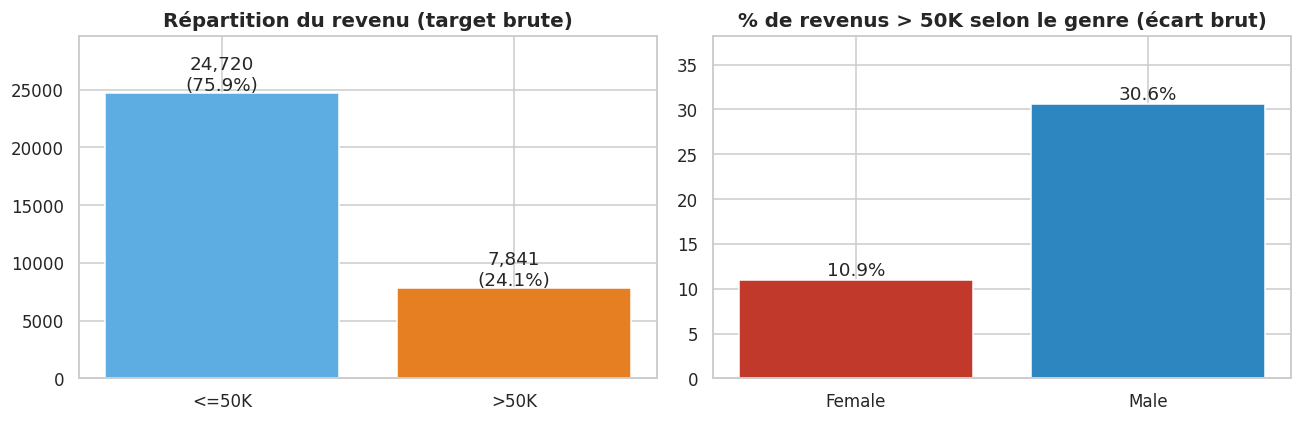

📸 capture enregistrée : captures/10_target_et_ecart_genre.png


In [ ]:
print("Labels bruts de income :", df_raw["income"].unique())
vc = df_raw["income"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(vc.index, vc.values, color=["#5DADE2", "#E67E22"])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 200, f"{v:,}\n({v/len(df_raw)*100:.1f}%)", ha="center")
axes[0].set_title("Répartition du revenu (target brute)"); axes[0].set_ylim(0, vc.max() * 1.2)

rate_sex = df_raw.groupby("sex")["income"].apply(lambda s: (s == ">50K").mean() * 100)
axes[1].bar(rate_sex.index, rate_sex.values, color=["#C0392B", "#2E86C1"])
for i, v in enumerate(rate_sex.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center")
axes[1].set_title("% de revenus > 50K selon le genre (écart brut)"); axes[1].set_ylim(0, rate_sex.max() * 1.25)
plt.tight_layout(); save_fig("10_target_et_ecart_genre")

## 1.9 Synthèse des problèmes détectés → plan de nettoyage

,Problème,Colonne(s),Ampleur,Action prévue (Étape 2)
0,Valeurs manquantes cachées ('?'),"workclass, occupation, native-country","1,836 / 1,843 / 583 lignes",Convertir en NaN puis traiter
1,Doublons exacts,toutes,24 lignes,Supprimer
2,Colonnes redondantes,education / education-num ; relationship,correspondance 1-pour-1 ; V élevé avec marital...,Supprimer une des deux
3,Colonne non pertinente,fnlwgt,poids d'échantillonnage du recensement,Supprimer
4,Quasi-constante,native-country,90 % = United-States,Supprimer
5,Valeurs aberrantes / plafond,"capital-gain, capital-loss","92 % de zéros, 159 valeurs = 99999",Supprimer (revenus non salariaux)
6,Valeurs extrêmes,hours-per-week,208 lignes > 80 h/sem,Plafonner (winsorisation)
7,Target non conforme au Module 1,income,"target brute = revenu ≤/> 50K, pas un indicate...",Construire la target binaire d'équité


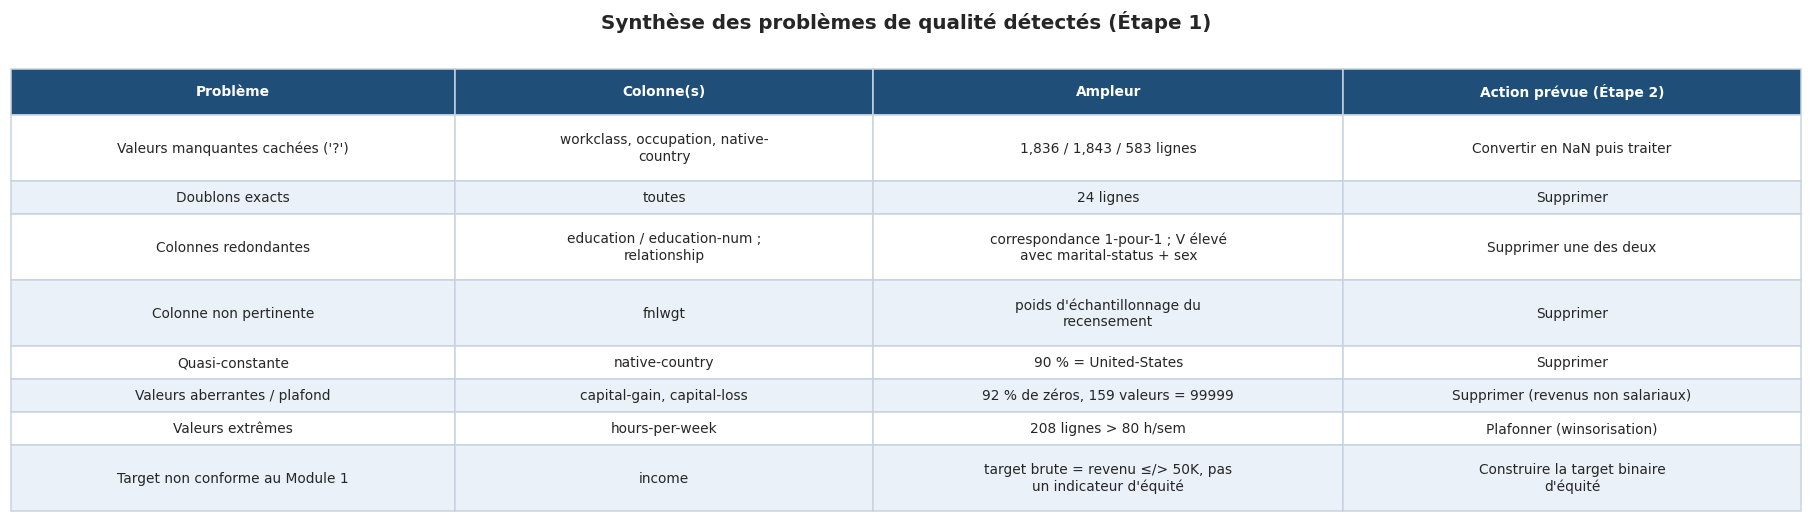

📸 capture enregistrée : captures/11_synthese_problemes.png


In [ ]:
pb = pd.DataFrame([
    ["Valeurs manquantes cachées ('?')", "workclass, occupation, native-country",
     f"{q_count['workclass']:,} / {q_count['occupation']:,} / {q_count['native-country']:,} lignes", "Convertir en NaN puis traiter"],
    ["Doublons exacts", "toutes", f"{n_dup} lignes", "Supprimer"],
    ["Colonnes redondantes", "education / education-num ; relationship", "correspondance 1-pour-1 ; V élevé avec marital-status + sex", "Supprimer une des deux"],
    ["Colonne non pertinente", "fnlwgt", "poids d'échantillonnage du recensement", "Supprimer"],
    ["Quasi-constante", "native-country", f"{top_share['native-country']:.0f} % = United-States", "Supprimer"],
    ["Valeurs aberrantes / plafond", "capital-gain, capital-loss", f"{(df_raw['capital-gain']==0).mean()*100:.0f} % de zéros, {n99} valeurs = 99999", "Supprimer (revenus non salariaux)"],
    ["Valeurs extrêmes", "hours-per-week", f"{(df_raw['hours-per-week']>80).sum()} lignes > 80 h/sem", "Plafonner (winsorisation)"],
    ["Target non conforme au Module 1", "income", "target brute = revenu ≤/> 50K, pas un indicateur d'équité", "Construire la target binaire d'équité"],
], columns=["Problème", "Colonne(s)", "Ampleur", "Action prévue (Étape 2)"])
display(pb)
save_table(pb, "11_synthese_problemes", title="Synthèse des problèmes de qualité détectés (Étape 1)", wrap=34, fs=9)

---
# ÉTAPE 2 — Nettoyage approfondi (features + target)

**Règle de travail :** chaque suppression est **justifiée avec une preuve chiffrée**. Le journal des décisions (`journal`) est rempli au fur et à mesure et exporté en image à la fin.

In [ ]:
df = df_raw.copy()                       # on garde df_raw intact pour les comparaisons AVANT / APRÈS
journal = []                             # (étape, décision, justification)
def log(etape, decision, justification):
    journal.append([etape, decision, justification])

def n_missing(d):
    return int(d.isna().sum().sum() + (d == "?").sum().sum())
print("Copie de travail créée :", df.shape)

Copie de travail créée : (32561, 15)


## 2.1 Doublons
**Décision : supprimer.** Le dataset n'a pas d'identifiant. Mais deux personnes différentes qui partageraient les **15 champs identiques, y compris `fnlwgt`** (poids quasi-unique, plus de 21 000 valeurs distinctes), est très improbable : ce sont des copies de saisie.

In [ ]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
dup_after = int(df.duplicated().sum())
print(f"Doublons supprimés : {before - len(df)}  ({before:,} → {len(df):,} lignes)")
print(f"fnlwgt : {df_raw['fnlwgt'].nunique():,} valeurs distinctes sur {len(df_raw):,} lignes")
log("Doublons", f"Suppression de {before-len(df)} lignes dupliquées",
    "Aucun ID, mais 15 champs identiques dont fnlwgt (quasi-unique) = copie de saisie, pas deux personnes. Perte négligeable (0,07 %).")

Doublons supprimés : 24  (32,561 → 32,537 lignes)
fnlwgt : 21,648 valeurs distinctes sur 32,561 lignes


## 2.2 Colonnes redondantes ou non pertinentes
Chaque colonne supprimée est justifiée par une mesure.

In [ ]:
ev = []   # tableau de preuves

# (a) education  <->  education-num
ev.append(["education", "Supprimer (garder education-num)",
           "Correspondance 1-pour-1 avec education-num (16 niveaux ↔ 16 codes). education-num est déjà ordinale (1→16) : "
           "utilisable directement par le modèle, sans encodage, et conserve l'ordre des diplômes."])

# (b) relationship
v_rs = cramers_v(df["relationship"], df["sex"]); v_rm = cramers_v(df["relationship"], df["marital-status"])
ev.append(["relationship", "Supprimer",
           f"Redondante avec marital-status (V={v_rm:.2f}) et sex (V={v_rs:.2f}) : 'Husband'/'Wife' = statut marital + genre. "
           "Elle réintroduirait le genre par la petite porte alors que le genre doit servir à auditer l'équité, pas à la prédire."])

# (c) fnlwgt
corr_fn = df["fnlwgt"].corr((df["income"] == ">50K").astype(int))
ev.append(["fnlwgt", "Supprimer",
           f"Poids statistique d'échantillonnage du recensement US : ce n'est pas une caractéristique du collaborateur. "
           f"Corrélation avec le revenu quasi nulle (r={corr_fn:.3f})."])

# (d) native-country
us = (df["native-country"] == "United-States").mean() * 100
ev.append(["native-country", "Supprimer",
           f"Quasi-constante : {us:.0f} % = United-States ; 583 '?' en plus. Très peu d'information utile, et variable sensible (discrimination à l'origine)."])

# (e) capital-gain / capital-loss
z_g = (df["capital-gain"] == 0).mean() * 100; z_l = (df["capital-loss"] == 0).mean() * 100
ev.append(["capital-gain, capital-loss", "Supprimer",
           f"{z_g:.0f} % / {z_l:.0f} % de zéros ; capital-gain contient un code plafond 99 999 (non réel). Ce sont des revenus du patrimoine "
           "(plus-values), pas de la rémunération du travail : hors périmètre de l'équité salariale (âge, études, poste, volume horaire)."])

evid = pd.DataFrame(ev, columns=["Colonne", "Décision", "Justification (preuve)"])
display(evid)

drop_cols = ["education", "relationship", "fnlwgt", "native-country", "capital-gain", "capital-loss"]
df = df.drop(columns=drop_cols)
for col, dec, why in ev:
    log("Colonnes redondantes", f"{col} → {dec}", why)
print("Colonnes restantes :", list(df.columns))

,Colonne,Décision,Justification (preuve)
0,education,Supprimer (garder education-num),Correspondance 1-pour-1 avec education-num (16...
1,relationship,Supprimer,Redondante avec marital-status (V=0.49) et sex...
2,fnlwgt,Supprimer,Poids statistique d'échantillonnage du recense...
3,native-country,Supprimer,Quasi-constante : 90 % = United-States ; 583 '...
4,"capital-gain, capital-loss",Supprimer,92 % / 95 % de zéros ; capital-gain contient u...


Colonnes restantes : ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'race', 'sex', 'hours-per-week', 'income']


## 2.3 Valeurs manquantes (`?` → NaN → traitement)
Avant de supprimer des lignes, on vérifie que **les lignes manquantes ne sont pas un groupe particulier** (sinon la suppression biaiserait l'étude d'équité).

Lignes avec workclass ou occupation manquant : 1,843 (5.66 %)


,Lignes avec manquants,Lignes complètes
Nombre de lignes,1843.00,30694.00
% revenu > 50K,10.36,24.92
Âge moyen,40.88,38.45
Heures/sem. moyennes,31.91,40.95
% de femmes,45.63,32.32


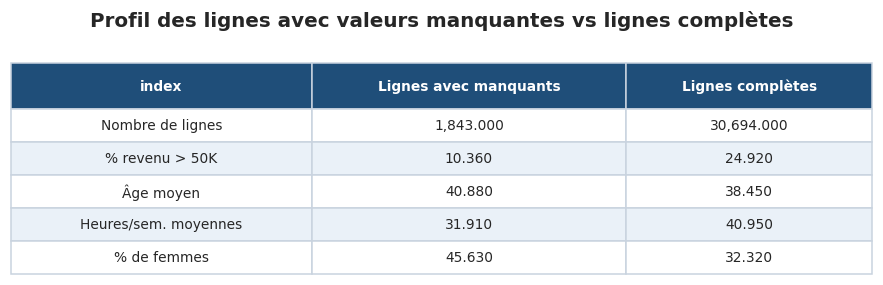

📸 capture enregistrée : captures/12_manquants_vs_complets.png

workclass des lignes sans 'occupation' :
workclass
NaN             1836
Never-worked       7


In [ ]:
df = df.replace("?", np.nan)                          # les '?' deviennent de vrais NaN
miss_rows = df["workclass"].isna() | df["occupation"].isna()
print(f"Lignes avec workclass ou occupation manquant : {miss_rows.sum():,} ({miss_rows.mean()*100:.2f} %)")

cmp = pd.DataFrame({
    "Lignes avec manquants": [miss_rows.sum(), (df.loc[miss_rows, "income"] == ">50K").mean() * 100,
                              df.loc[miss_rows, "age"].mean(), df.loc[miss_rows, "hours-per-week"].mean(),
                              (df.loc[miss_rows, "sex"] == "Female").mean() * 100],
    "Lignes complètes":      [(~miss_rows).sum(), (df.loc[~miss_rows, "income"] == ">50K").mean() * 100,
                              df.loc[~miss_rows, "age"].mean(), df.loc[~miss_rows, "hours-per-week"].mean(),
                              (df.loc[~miss_rows, "sex"] == "Female").mean() * 100],
}, index=["Nombre de lignes", "% revenu > 50K", "Âge moyen", "Heures/sem. moyennes", "% de femmes"]).round(2)
display(cmp)
save_table(cmp, "12_manquants_vs_complets", title="Profil des lignes avec valeurs manquantes vs lignes complètes", index=True)

print("\nworkclass des lignes sans 'occupation' :")
print(df.loc[df["occupation"].isna(), "workclass"].value_counts(dropna=False).to_string())

In [ ]:
before_rate = (df["income"] == ">50K").mean() * 100
before_f = (df["sex"] == "Female").mean() * 100
df = df.dropna(subset=["workclass", "occupation"]).reset_index(drop=True)
after_rate = (df["income"] == ">50K").mean() * 100
after_f = (df["sex"] == "Female").mean() * 100
print(f"% revenu > 50K : {before_rate:.2f} % → {after_rate:.2f} %  |  % de femmes : {before_f:.2f} % → {after_f:.2f} %")
print(f"Lignes : {len(df):,}   |   NaN restants : {int(df.isna().sum().sum())}")

log("Valeurs manquantes", "Suppression des lignes où workclass ou occupation = '?' (≈ 5,7 % des lignes)",
    f"occupation (le poste) est une feature clé du module : l'imputer par le mode inventerait un métier et fausserait la comparaison "
    f"au standard de rémunération. Les deux manques coïncident (même non-réponse), le volume est faible (<6 %) et la suppression ne "
    f"déforme pas la population (revenu>50K : {before_rate:.1f}% → {after_rate:.1f}% ; femmes : {before_f:.1f}% → {after_f:.1f}%).")

% revenu > 50K : 24.09 % → 24.92 %  |  % de femmes : 33.08 % → 32.32 %
Lignes : 30,694   |   NaN restants : 0


## 2.4 Valeurs aberrantes
- **`age`** : le maximum 90 est le plafond du recensement (valeur réelle regroupée), pas une erreur → **conservé**.
- **`hours-per-week`** : la règle IQR est inadaptée ici (pic massif à 40 h qui rend l'IQR minuscule et marque ~26 % des lignes comme "aberrantes"). On applique une **règle métier** : au-delà de 80 h/semaine les valeurs sont peu crédibles → **plafonnement à 80 h** (winsorisation), sans supprimer de ligne.
- **`education-num`** : 1 → 16, plage valide → conservé.

Règle IQR sur hours-per-week : 26.4 % de lignes 'aberrantes' → règle trop agressive, non retenue
Lignes > 80 h/semaine plafonnées à 80 : 198  (max avant = 99)


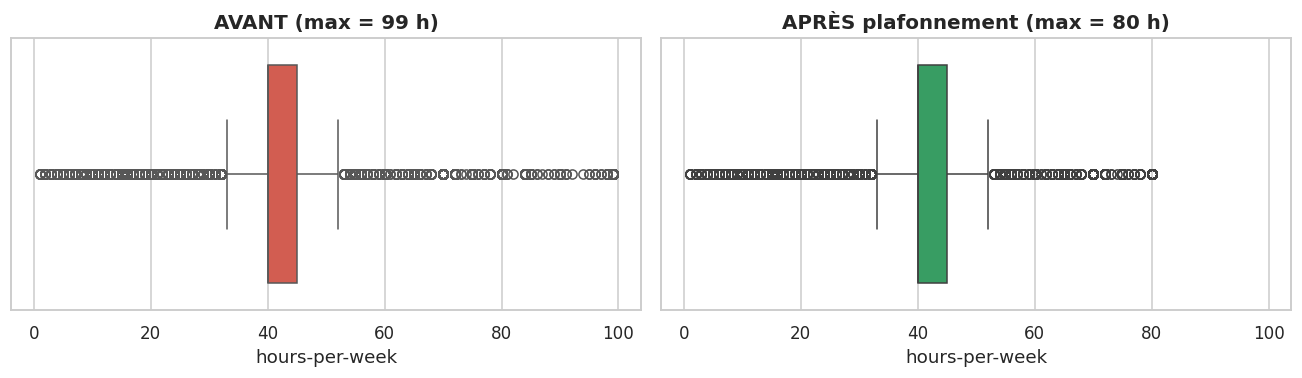

📸 capture enregistrée : captures/13_outliers_hours_avant_apres.png


In [ ]:
hours_before = df["hours-per-week"].copy()
q1, q3 = hours_before.quantile([.25, .75])
iqr_flag = ((hours_before < q1 - 1.5 * (q3 - q1)) | (hours_before > q3 + 1.5 * (q3 - q1))).mean() * 100
n_cap = int((hours_before > 80).sum())
print(f"Règle IQR sur hours-per-week : {iqr_flag:.1f} % de lignes 'aberrantes' → règle trop agressive, non retenue")
print(f"Lignes > 80 h/semaine plafonnées à 80 : {n_cap}  (max avant = {hours_before.max()})")

df["hours-per-week"] = df["hours-per-week"].clip(upper=80)

log("Valeurs aberrantes", f"hours-per-week plafonné à 80 h ({n_cap} lignes) ; age conservé",
    f"IQR marque {iqr_flag:.0f} % des lignes (pic à 40 h) → inadapté. Seuil métier 80 h : au-delà peu crédible. Le plafonnement garde "
    "la ligne (aucune perte d'information sur les autres variables). age=90 = plafond de recensement, valeur réelle → conservé.")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharex=True)
sns.boxplot(x=hours_before, ax=axes[0], color="#E74C3C"); axes[0].set_title(f"AVANT (max = {hours_before.max()} h)")
sns.boxplot(x=df["hours-per-week"], ax=axes[1], color="#27AE60"); axes[1].set_title(f"APRÈS plafonnement (max = {df['hours-per-week'].max()} h)")
for a in axes: a.set_xlabel("hours-per-week")
plt.tight_layout(); save_fig("13_outliers_hours_avant_apres")

## 2.5 Nettoyage de la target — construction de l'indicateur d'équité salariale
Le Module 1 exige une **cible binaire dérivée des données** : `0` = rémunération conforme aux qualifications et au poste ; `1` = écart salarial inexpliqué.

**1. Nettoyage du label brut** : on retire les espaces parasites et on encode `income` (`>50K` = 1).

**2. Rémunération attendue** : on entraîne un modèle de référence qui prédit la probabilité d'être payé `>50K` **uniquement à partir des qualifications et du poste** (`age`, `education-num`, `hours-per-week`, `workclass`, `occupation`). Les attributs sensibles (`sex`, `race`, `marital-status`) en sont **volontairement exclus**. Les probabilités sont calculées en **validation croisée 5 plis**, donc chaque personne est évaluée par un modèle qui ne l'a jamais vue.

**3. Règle d'écart inexpliqué (`target = 1`)** :
- **sous-payé** : revenu réel `≤ 50K` alors que le profil "attend" `>50K` (probabilité ≥ 0,50) ;
- **sur-payé / atypique** : revenu réel `>50K` alors que le profil rend cela très improbable (probabilité ≤ 0,10).

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier

# 1) nettoyage du label
df["income"] = df["income"].astype(str).str.strip().str.replace(".", "", regex=False)
assert set(df["income"].unique()) == {"<=50K", ">50K"}, df["income"].unique()
df["income_bin"] = (df["income"] == ">50K").astype(int)

# 2) rémunération attendue à partir des seules qualifications / du poste
QUALIF_NUM = ["age", "education-num", "hours-per-week"]
QUALIF_CAT = ["workclass", "occupation"]
ref_model = Pipeline([
    ("prep", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), QUALIF_CAT)],
                               remainder="passthrough")),
    ("clf", HistGradientBoostingClassifier(max_depth=4, random_state=RANDOM_STATE)),
])
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
df["p_attendu"] = cross_val_predict(ref_model, df[QUALIF_NUM + QUALIF_CAT], df["income_bin"], cv=cv, method="predict_proba")[:, 1]

# 3) règle d'écart inexpliqué
SEUIL_SOUS_PAYE, SEUIL_SUR_PAYE = 0.50, 0.10
sous = (df["income_bin"] == 0) & (df["p_attendu"] >= SEUIL_SOUS_PAYE)
sur  = (df["income_bin"] == 1) & (df["p_attendu"] <= SEUIL_SUR_PAYE)
df["target"] = (sous | sur).astype(int)
df["type_ecart"] = np.select([sous, sur], ["Sous-payé vs profil", "Sur-payé / atypique"], default="Conforme")

print(df["type_ecart"].value_counts().to_string())
print(f"\nTarget = 1 : {df['target'].mean()*100:.1f} % des collaborateurs")

type_ecart
Conforme               28633
Sous-payé vs profil     1692
Sur-payé / atypique      369

Target = 1 : 6.7 % des collaborateurs


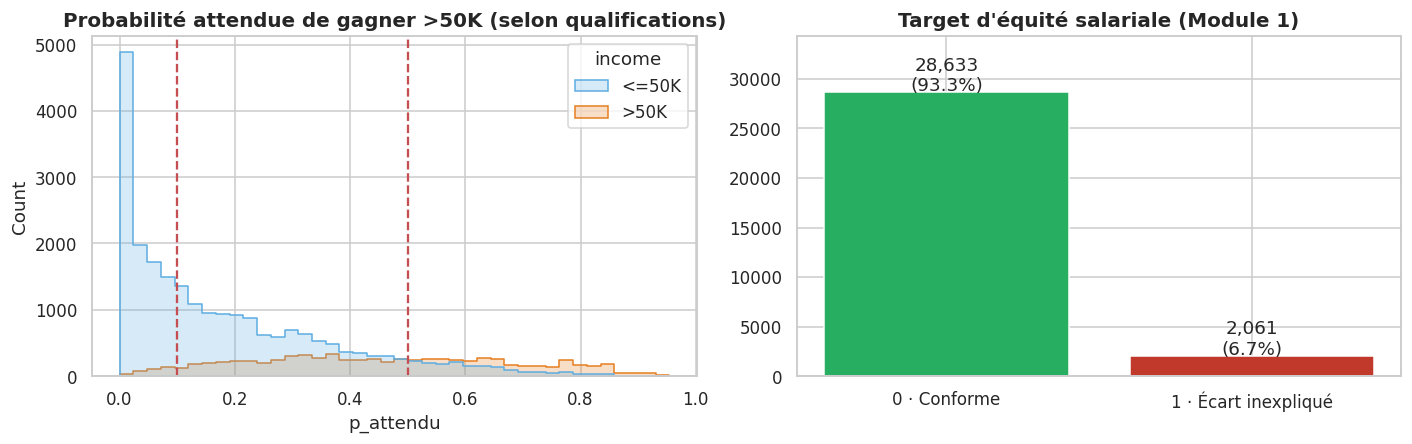

📸 capture enregistrée : captures/14_construction_target.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(data=df, x="p_attendu", hue="income", bins=40, ax=axes[0], palette=["#5DADE2", "#E67E22"], element="step")
axes[0].axvline(SEUIL_SOUS_PAYE, ls="--", c="r"); axes[0].axvline(SEUIL_SUR_PAYE, ls="--", c="r")
axes[0].set_title("Probabilité attendue de gagner >50K (selon qualifications)")
axes[0].set_xlabel("p_attendu")
vc = df["target"].value_counts().sort_index()
axes[1].bar(["0 · Conforme", "1 · Écart inexpliqué"], vc.values, color=["#27AE60", "#C0392B"])
for i, v in enumerate(vc.values):
    axes[1].text(i, v + 150, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center")
axes[1].set_title("Target d'équité salariale (Module 1)"); axes[1].set_ylim(0, vc.max() * 1.2)
plt.tight_layout(); save_fig("14_construction_target")

log("Target", "Nettoyage du label income + construction de la target binaire d'équité",
    f"Cible demandée par le Module 1 (0 conforme / 1 écart inexpliqué). Rémunération attendue = modèle sur qualifications+poste uniquement "
    f"(sex/race exclus), CV 5 plis ; target=1 si sous-payé (p≥{SEUIL_SOUS_PAYE}) ou sur-payé atypique (p≤{SEUIL_SUR_PAYE}). "
    f"Taux de target=1 : {df['target'].mean()*100:.1f} %.")

## 2.6 Bilan AVANT / APRÈS

,AVANT,APRÈS
Lignes,"32,561","30,694"
Colonnes,15,13
Doublons exacts (15 champs),24,0
Valeurs manquantes (NaN + '?'),4262,0
hours-per-week max,99,80
Colonnes redondantes / non pertinentes,6,0


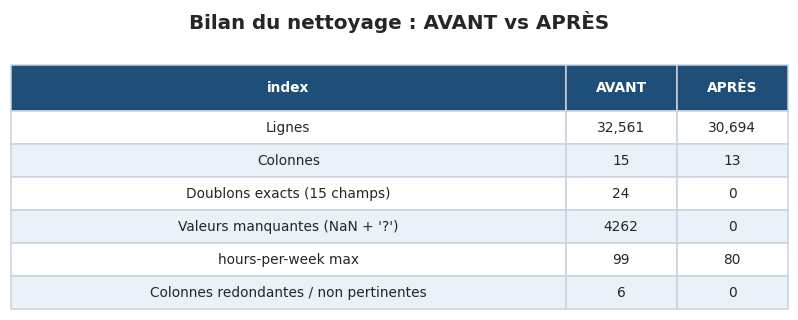

📸 capture enregistrée : captures/15_bilan_avant_apres.png


In [ ]:
def resume(d, label):
    return pd.Series({
        "Lignes": f"{len(d):,}",
        "Colonnes": d.shape[1],
        "Doublons exacts (15 champs)": int(d.duplicated().sum()) if label == "AVANT" else dup_after,
        "Valeurs manquantes (NaN + '?')": n_missing(d),
        "hours-per-week max": int(d["hours-per-week"].max()),
        "Colonnes redondantes / non pertinentes": 6 if label == "AVANT" else 0,
    }, name=label)

df_final_cols = [c for c in df.columns]
bilan = pd.concat([resume(df_raw, "AVANT"), resume(df, "APRÈS")], axis=1)
display(bilan)
save_table(bilan, "15_bilan_avant_apres", title="Bilan du nettoyage : AVANT vs APRÈS", index=True)

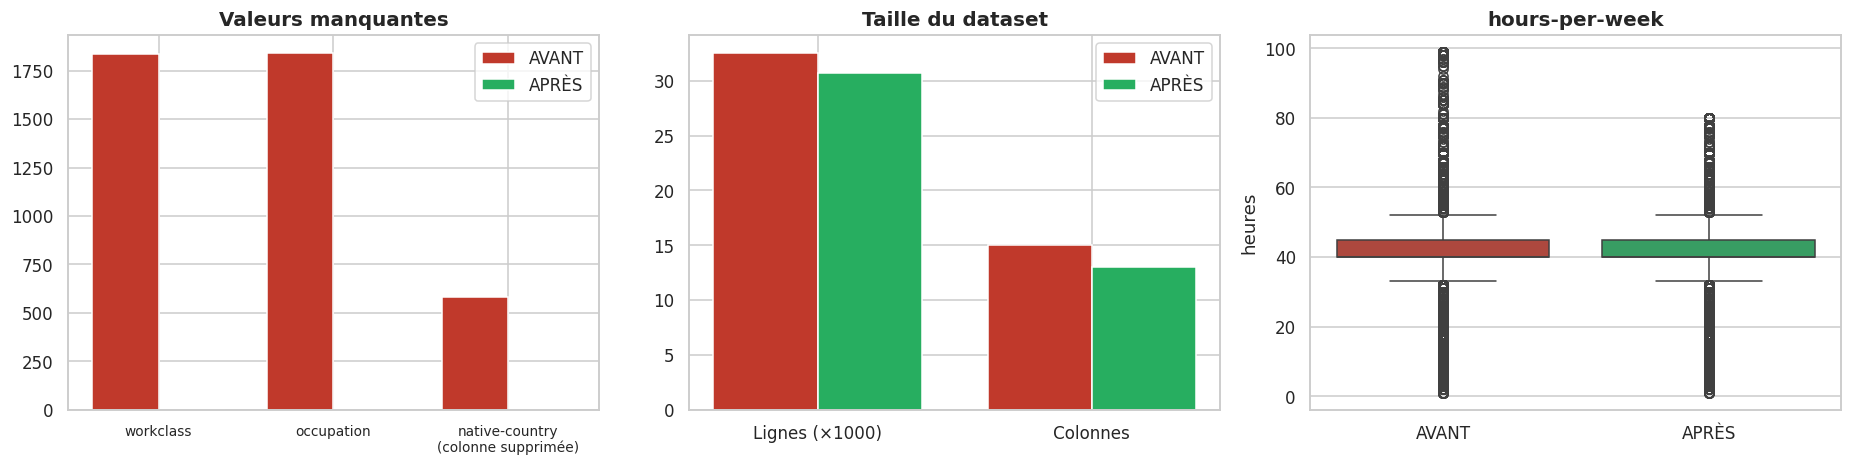

📸 capture enregistrée : captures/16_avant_apres_graphiques.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))

# (a) valeurs manquantes par colonne
mb = (df_raw == "?").sum()[["workclass", "occupation", "native-country"]]
ma = pd.Series({c: df[c].isna().sum() if c in df.columns else 0 for c in mb.index})
x = np.arange(len(mb)); w = 0.38
axes[0].bar(x - w/2, mb.values, w, label="AVANT", color="#C0392B")
axes[0].bar(x + w/2, ma.values, w, label="APRÈS", color="#27AE60")
axes[0].set_xticks(x); axes[0].set_xticklabels(["workclass", "occupation", "native-country\n(colonne supprimée)"], fontsize=9)
axes[0].set_title("Valeurs manquantes"); axes[0].legend()

# (b) nombre de colonnes / lignes
labels = ["Lignes (×1000)", "Colonnes"]
axes[1].bar(np.arange(2) - w/2, [len(df_raw)/1000, df_raw.shape[1]], w, label="AVANT", color="#C0392B")
axes[1].bar(np.arange(2) + w/2, [len(df)/1000, df.shape[1]], w, label="APRÈS", color="#27AE60")
axes[1].set_xticks(range(2)); axes[1].set_xticklabels(labels); axes[1].set_title("Taille du dataset"); axes[1].legend()

# (c) hours-per-week
sns.boxplot(data=pd.DataFrame({"AVANT": df_raw["hours-per-week"].reset_index(drop=True), "APRÈS": df["hours-per-week"].reset_index(drop=True)}),
            ax=axes[2], palette=["#C0392B", "#27AE60"])
axes[2].set_title("hours-per-week"); axes[2].set_ylabel("heures")
plt.tight_layout(); save_fig("16_avant_apres_graphiques")

,Étape,Décision,Justification
0,Doublons,Suppression de 24 lignes dupliquées,"Aucun ID, mais 15 champs identiques dont fnlwg..."
1,Colonnes redondantes,education → Supprimer (garder education-num),Correspondance 1-pour-1 avec education-num (16...
2,Colonnes redondantes,relationship → Supprimer,Redondante avec marital-status (V=0.49) et sex...
3,Colonnes redondantes,fnlwgt → Supprimer,Poids statistique d'échantillonnage du recense...
4,Colonnes redondantes,native-country → Supprimer,Quasi-constante : 90 % = United-States ; 583 '...
5,Colonnes redondantes,"capital-gain, capital-loss → Supprimer",92 % / 95 % de zéros ; capital-gain contient u...
6,Valeurs manquantes,Suppression des lignes où workclass ou occupat...,occupation (le poste) est une feature clé du m...
7,Valeurs aberrantes,hours-per-week plafonné à 80 h (198 lignes) ; ...,IQR marque 26 % des lignes (pic à 40 h) → inad...
8,Target,Nettoyage du label income + construction de la...,Cible demandée par le Module 1 (0 conforme / 1...


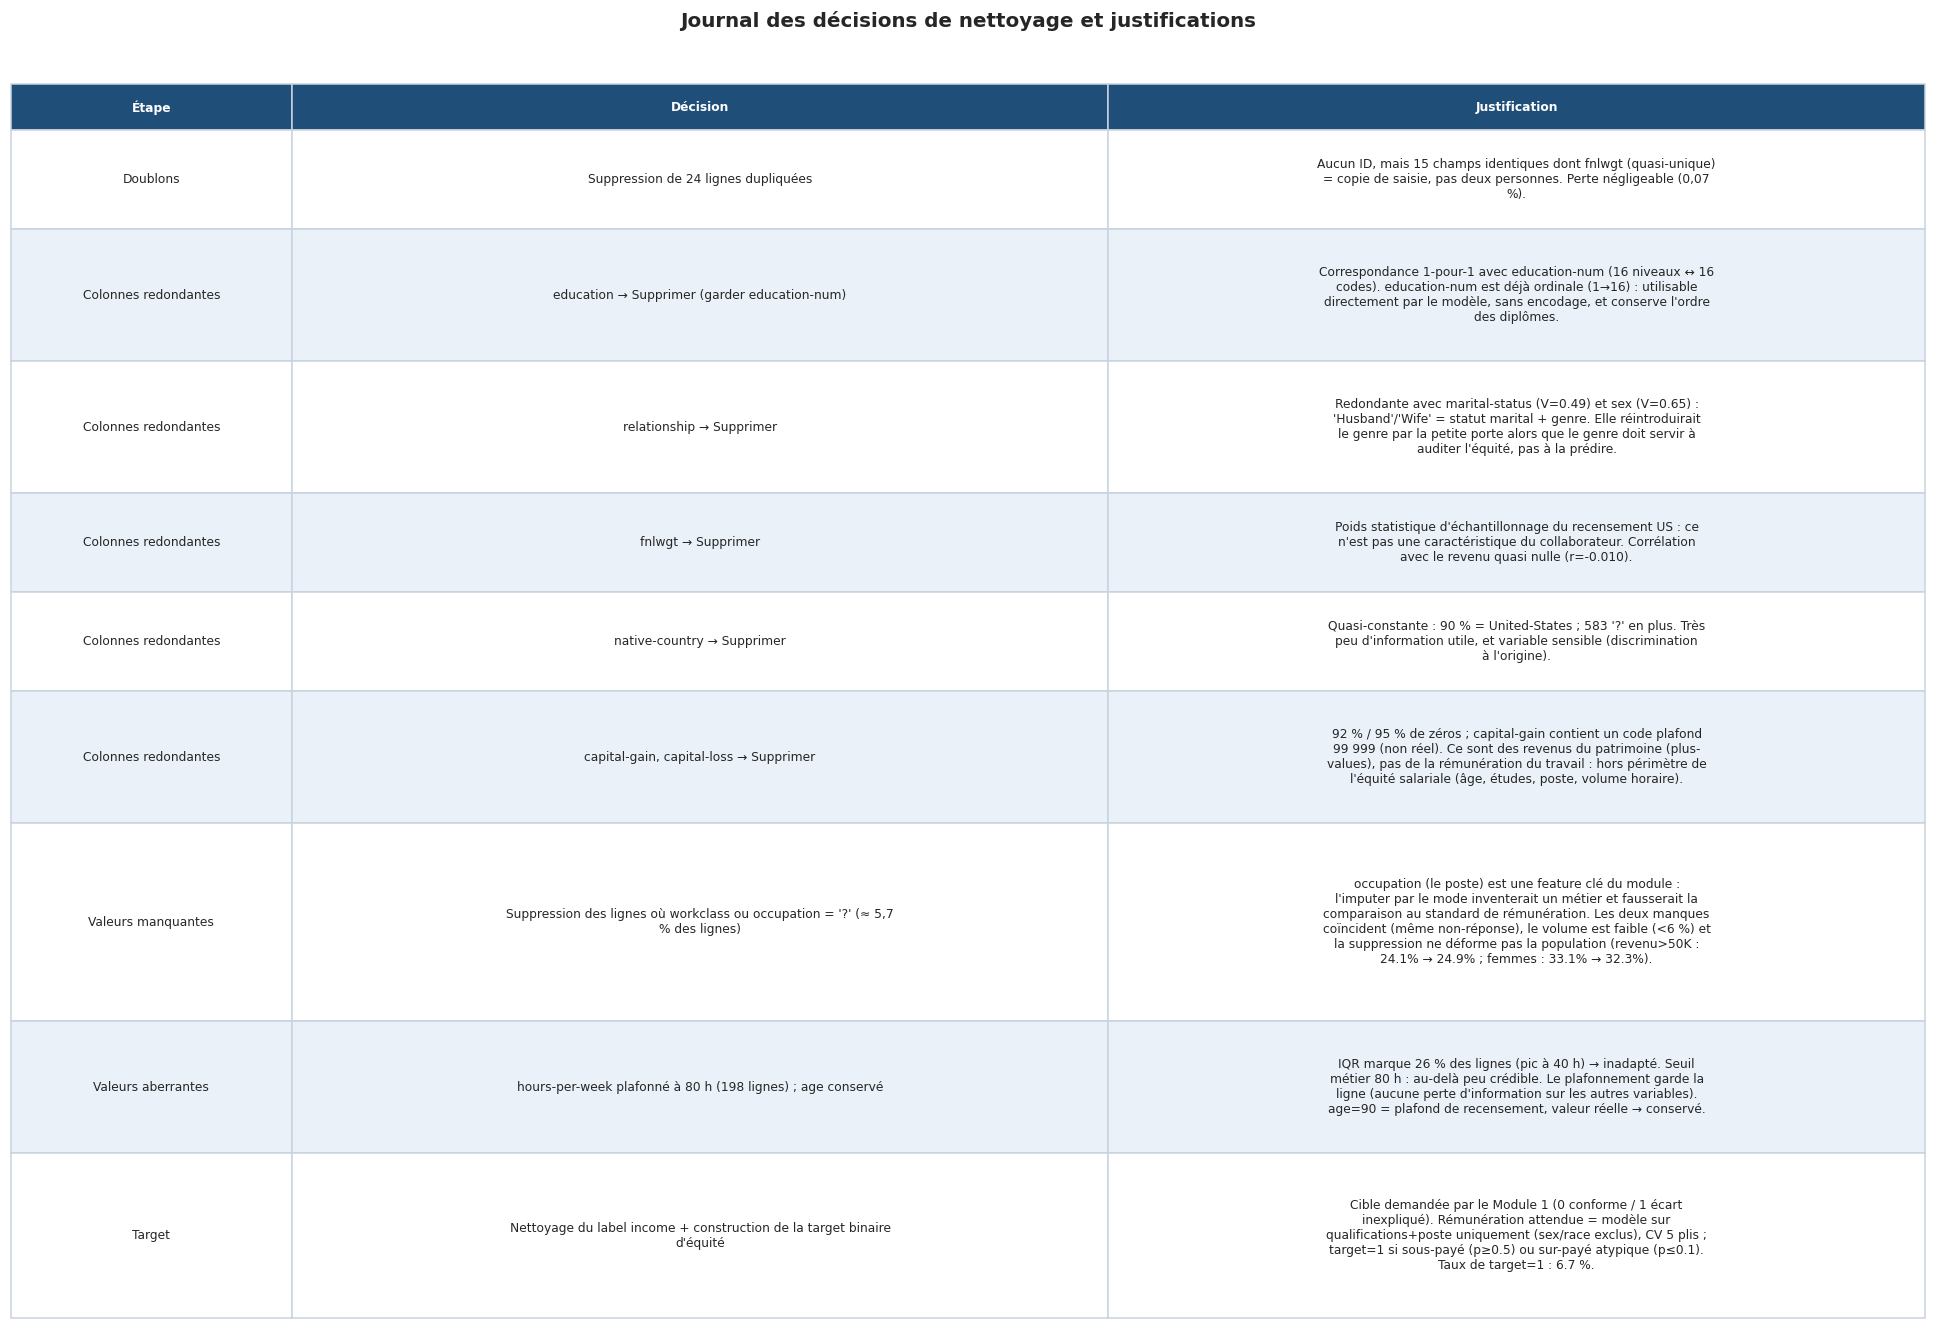

📸 capture enregistrée : captures/17_journal_decisions_justifications.png
✔ Dataset nettoyé : (30694, 13) → adult_module1_clean.csv


,age,workclass,education-num,marital-status,occupation,sex,race,hours-per-week,income,income_bin,p_attendu,type_ecart,target
0,39,State-gov,13,Never-married,Adm-clerical,Male,White,40,<=50K,0,0.239272,Conforme,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Male,White,13,<=50K,0,0.505546,Sous-payé vs profil,1
2,38,Private,9,Divorced,Handlers-cleaners,Male,White,40,<=50K,0,0.114089,Conforme,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Male,Black,40,<=50K,0,0.089304,Conforme,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Female,Black,40,<=50K,0,0.281747,Conforme,0


In [ ]:
jr = pd.DataFrame(journal, columns=["Étape", "Décision", "Justification"])
display(jr)
save_table(jr, "17_journal_decisions_justifications", title="Journal des décisions de nettoyage et justifications", wrap=62, fs=8)

# On ne garde que les colonnes utiles pour la suite
keep = ["age", "workclass", "education-num", "marital-status", "occupation", "sex", "race",
        "hours-per-week", "income", "income_bin", "p_attendu", "type_ecart", "target"]
df_clean = df[keep].copy()
df_clean.to_csv("adult_module1_clean.csv", index=False)
print("✔ Dataset nettoyé :", df_clean.shape, "→ adult_module1_clean.csv")
display(df_clean.head())

---
# ÉTAPE 3 — Matrice de sélection des features

**Objectif :** mesurer l'importance de chaque variable candidate vis-à-vis de la target, puis retenir **4 à 5 features maximum**.

La matrice croise **3 mesures indépendantes** (chacune normalisée de 0 à 1 puis moyennée en un score global) :

| Mesure | Ce qu'elle capte |
|---|---|
| **Information mutuelle** | toute dépendance (linéaire ou non) avec la target |
| **V de Cramér** (variables numériques découpées en déciles) | force de l'association statistique avec la target |
| **Importance par permutation** (AUC) | contribution réelle à la performance d'un modèle sur données de test |

On ajoute un contrôle de **redondance** (association maximale avec une autre feature) et un statut **sensible** : `sex`, `race` et `marital-status` (situation de famille : critère protégé en droit du travail) sont gardées pour **auditer** l'équité mais **jamais utilisées pour prédire**.

> ⚠ **Limite assumée :** la target est dérivée des qualifications (`age`, `education-num`, `hours-per-week`, `occupation`, `workclass`). Leur score élevé est donc en partie attendu ; l'intérêt de la matrice est surtout de **hiérarchiser** ces variables et de **montrer que les attributs sensibles n'ont pas de lien mécanique avec la target**.

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

CANDIDATES = ["age", "workclass", "education-num", "marital-status", "occupation", "hours-per-week", "sex", "race"]
SENSIBLES = {"sex", "race", "marital-status"}
y = df_clean["target"]
is_num = {c: pd.api.types.is_numeric_dtype(df_clean[c]) for c in CANDIDATES}

# --- encodage ordinal temporaire (uniquement pour les mesures)
Xo = df_clean[CANDIDATES].copy()
for c in CANDIDATES:
    if not is_num[c]:
        Xo[c] = Xo[c].astype("category").cat.codes
mask_cat = [not is_num[c] for c in CANDIDATES]

# 1) information mutuelle
mi = pd.Series(mutual_info_classif(Xo, y, discrete_features=mask_cat, random_state=RANDOM_STATE), index=CANDIDATES)

# 2) V de Cramér avec la target (numériques découpées en déciles)
def as_cat(c):
    return pd.qcut(df_clean[c], q=10, duplicates="drop") if is_num[c] else df_clean[c]
binned = {c: as_cat(c) for c in CANDIDATES}
cv_target = pd.Series({c: cramers_v(binned[c], y) for c in CANDIDATES})

# 3) importance par permutation (AUC) sur un jeu de test
Xtr, Xte, ytr, yte = train_test_split(Xo, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
hgb = HistGradientBoostingClassifier(categorical_features=mask_cat, max_depth=4, random_state=RANDOM_STATE).fit(Xtr, ytr)
pi = permutation_importance(hgb, Xte, yte, scoring="roc_auc", n_repeats=8, random_state=RANDOM_STATE)
perm = pd.Series(pi.importances_mean, index=CANDIDATES).clip(lower=0)

# 4) redondance : association max avec une AUTRE feature candidate
red = pd.Series({c: max(cramers_v(binned[c], binned[o]) for o in CANDIDATES if o != c) for c in CANDIDATES})

raw = pd.DataFrame({"Information mutuelle": mi, "V de Cramér (target)": cv_target, "Importance permutation (ΔAUC)": perm})
norm = (raw - raw.min()) / (raw.max() - raw.min())
raw["Score global (0-1)"] = norm.mean(axis=1)
raw["Redondance max (V)"] = red
raw["Sensible"] = ["OUI" if c in SENSIBLES else "non" for c in raw.index]
raw["Rang"] = raw["Score global (0-1)"].rank(ascending=False).astype(int)
matrice = raw.sort_values("Score global (0-1)", ascending=False)
display(matrice.round(4))

,Information mutuelle,V de Cramér (target),Importance permutation (ΔAUC),Score global (0-1),Redondance max (V),Sensible,Rang
education-num,0.0310,0.2598,0.1790,1.0000,0.3009,non,1
occupation,0.0242,0.2254,0.0677,0.6718,0.4336,non,2
age,0.0119,0.1415,0.0916,0.4718,0.2718,non,3
hours-per-week,0.0126,0.1454,0.0412,0.3906,0.2588,non,4
marital-status,0.0029,0.0763,0.0526,0.2149,0.4644,OUI,5
workclass,0.0051,0.1122,0.0095,0.2058,0.2151,non,6
race,0.0009,0.0400,0.0011,0.0473,0.1179,OUI,7
sex,0.0001,0.0111,0.0028,0.0032,0.4644,OUI,8


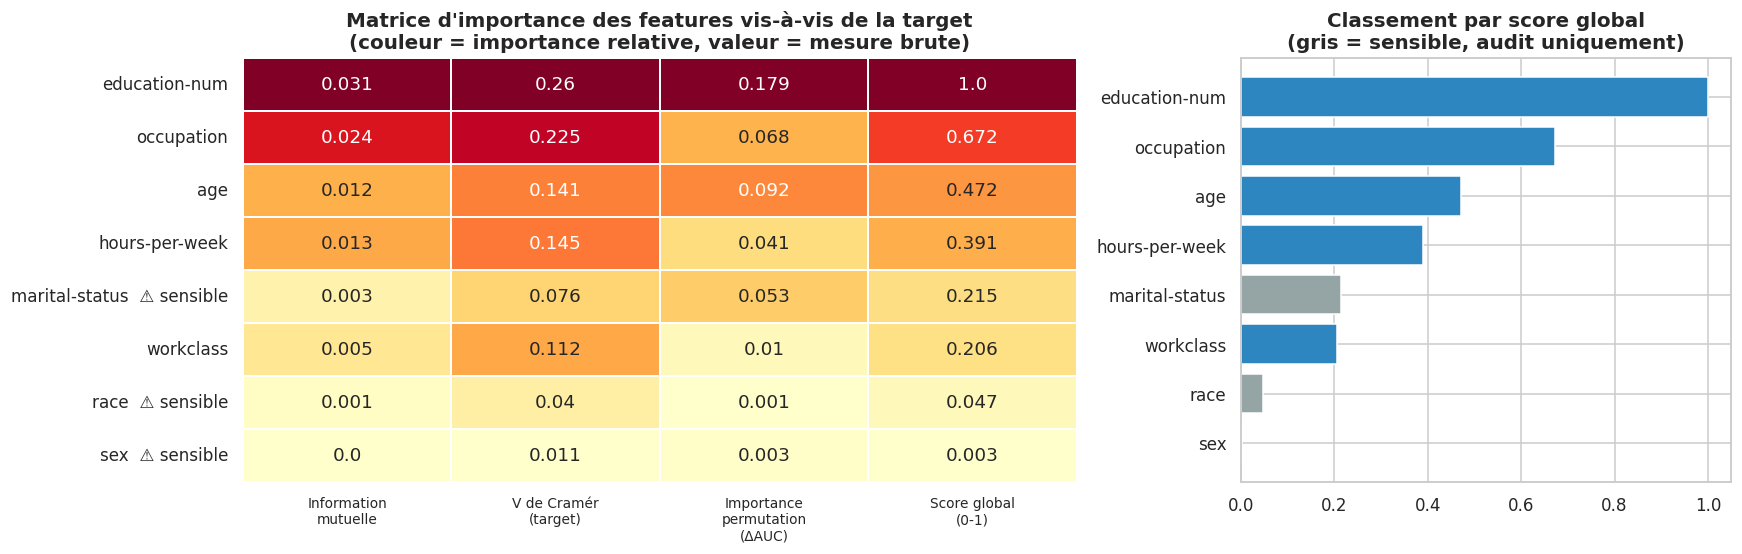

📸 capture enregistrée : captures/18_matrice_selection_features.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1.7, 1]})
order = matrice.index
metric_cols = ["Information mutuelle", "V de Cramér (target)", "Importance permutation (ΔAUC)", "Score global (0-1)"]
heat_norm = pd.concat([norm.loc[order], matrice.loc[order, ["Score global (0-1)"]]], axis=1)
annot = matrice.loc[order, metric_cols].round(3)
sns.heatmap(heat_norm[metric_cols], annot=annot.values, fmt="", cmap="YlOrRd", cbar=False, ax=axes[0],
            linewidths=1, linecolor="white")
axes[0].set_yticklabels([f"{c}  ⚠ sensible" if c in SENSIBLES else c for c in order], rotation=0)
axes[0].set_xticklabels([textwrap.fill(c, 16) for c in metric_cols], rotation=0, fontsize=9)
axes[0].set_title("Matrice d'importance des features vis-à-vis de la target\n(couleur = importance relative, valeur = mesure brute)")

colors = ["#95A5A6" if c in SENSIBLES else "#2E86C1" for c in order]
axes[1].barh(order[::-1], matrice.loc[order, "Score global (0-1)"][::-1], color=colors[::-1])
axes[1].set_title("Classement par score global\n(gris = sensible, audit uniquement)")
axes[1].set_xlim(0, 1.05)
plt.tight_layout(); save_fig("18_matrice_selection_features")

## Règle de décision (appliquée automatiquement)
1. Parcourir les features par **score global décroissant**.
2. **Exclure** les attributs sensibles (`sex`, `race`, `marital-status`) → réservés à l'audit.
3. **Écarter** toute feature trop redondante (V de Cramér > 0,60) avec une feature déjà retenue.
4. S'arrêter à **5 features maximum**, et ignorer celles dont le score global est quasi nul (< 0,05) ou dont la **contribution réelle au modèle** est marginale (ΔAUC par permutation < 0,02).

,Feature,Rang,Score global,Décision,Justification
0,education-num,1,1.000,RETENUE,"Score élevé, non redondante, non sensible."
1,occupation,2,0.672,RETENUE,"Score élevé, non redondante, non sensible."
2,age,3,0.472,RETENUE,"Score élevé, non redondante, non sensible."
3,hours-per-week,4,0.391,RETENUE,"Score élevé, non redondante, non sensible."
4,marital-status,5,0.215,EXCLUE (audit),Situation de famille : critère protégé en droi...
5,workclass,6,0.206,Écartée,Contribution marginale au modèle (ΔAUC = 0.010...
6,race,7,0.047,EXCLUE (audit),Attribut sensible : sert à mesurer l'écart de ...
7,sex,8,0.003,EXCLUE (audit),Attribut sensible : sert à mesurer l'écart de ...


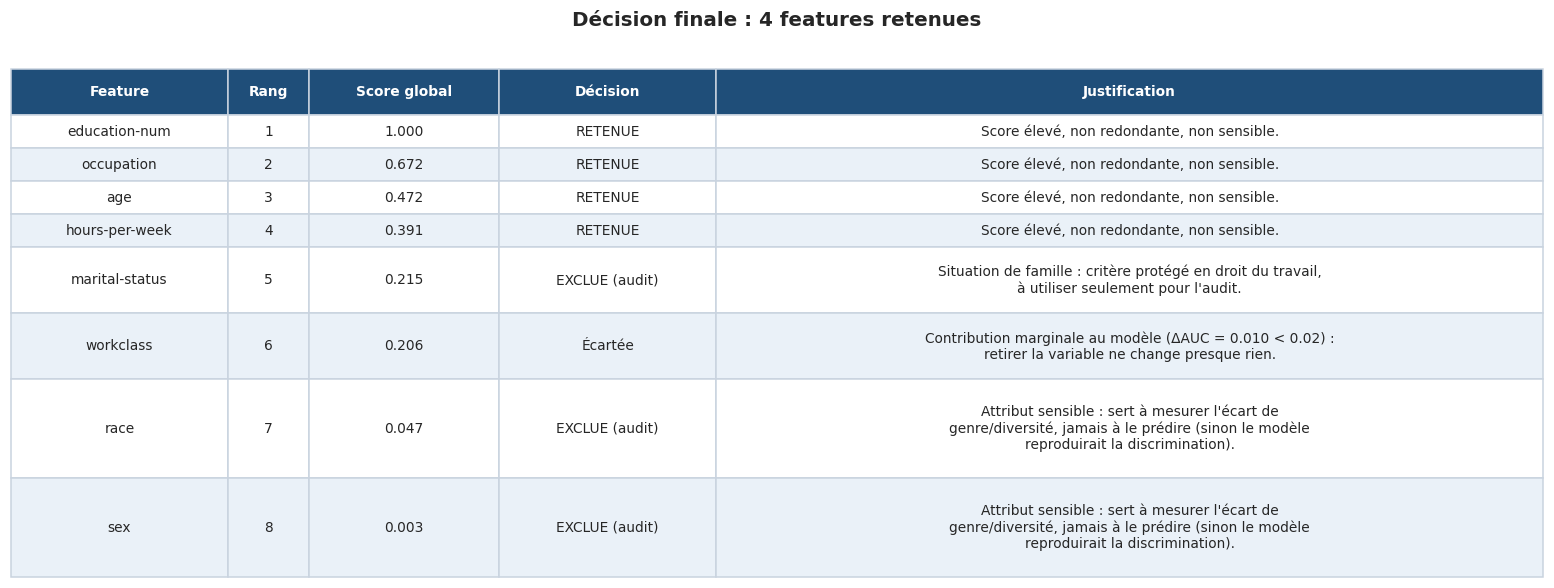

📸 capture enregistrée : captures/19_decision_selection_features.png

✅ FEATURES RETENUES : ['education-num', 'occupation', 'age', 'hours-per-week']


In [ ]:
MAX_FEATURES, SEUIL_REDONDANCE, SEUIL_SCORE, SEUIL_PERM = 5, 0.60, 0.05, 0.02
selected, decisions = [], []
for f in matrice.index:
    score = matrice.loc[f, "Score global (0-1)"]
    if f in SENSIBLES:
        decisions.append([f, matrice.loc[f, "Rang"], round(score, 3), "EXCLUE (audit)",
                          ("Situation de famille : critère protégé en droit du travail, à utiliser seulement pour l'audit." if f == "marital-status" else "Attribut sensible : sert à mesurer l'écart de genre/diversité, jamais à le prédire (sinon le modèle reproduirait la discrimination).")])
    elif len(selected) >= MAX_FEATURES:
        decisions.append([f, matrice.loc[f, "Rang"], round(score, 3), "Écartée", f"Limite de {MAX_FEATURES} features atteinte."])
    elif score < SEUIL_SCORE:
        decisions.append([f, matrice.loc[f, "Rang"], round(score, 3), "Écartée", f"Score global < {SEUIL_SCORE} : information quasi nulle pour la target."])
    elif matrice.loc[f, "Importance permutation (ΔAUC)"] < SEUIL_PERM:
        decisions.append([f, matrice.loc[f, "Rang"], round(score, 3), "Écartée",
                          f"Contribution marginale au modèle (ΔAUC = {matrice.loc[f, 'Importance permutation (ΔAUC)']:.3f} < {SEUIL_PERM}) : retirer la variable ne change presque rien."])
    else:
        conflits = [s for s in selected if cramers_v(binned[f], binned[s]) > SEUIL_REDONDANCE]
        if conflits:
            decisions.append([f, matrice.loc[f, "Rang"], round(score, 3), "Écartée", f"Redondante avec {conflits} (V > {SEUIL_REDONDANCE})."])
        else:
            selected.append(f)
            decisions.append([f, matrice.loc[f, "Rang"], round(score, 3), "RETENUE", "Score élevé, non redondante, non sensible."])

decision_df = pd.DataFrame(decisions, columns=["Feature", "Rang", "Score global", "Décision", "Justification"])
display(decision_df)
save_table(decision_df, "19_decision_selection_features", title=f"Décision finale : {len(selected)} features retenues", wrap=60, fs=9)
print("\n✅ FEATURES RETENUES :", selected)

## Pourquoi `sex` et `race` restent dans le projet : l'audit d'équité
Ces attributs ne sont **pas** dans le modèle, mais la target (construite sans eux) permet de vérifier si les écarts inexpliqués se concentrent sur certains groupes. C'est le cœur du détecteur d'injustice.

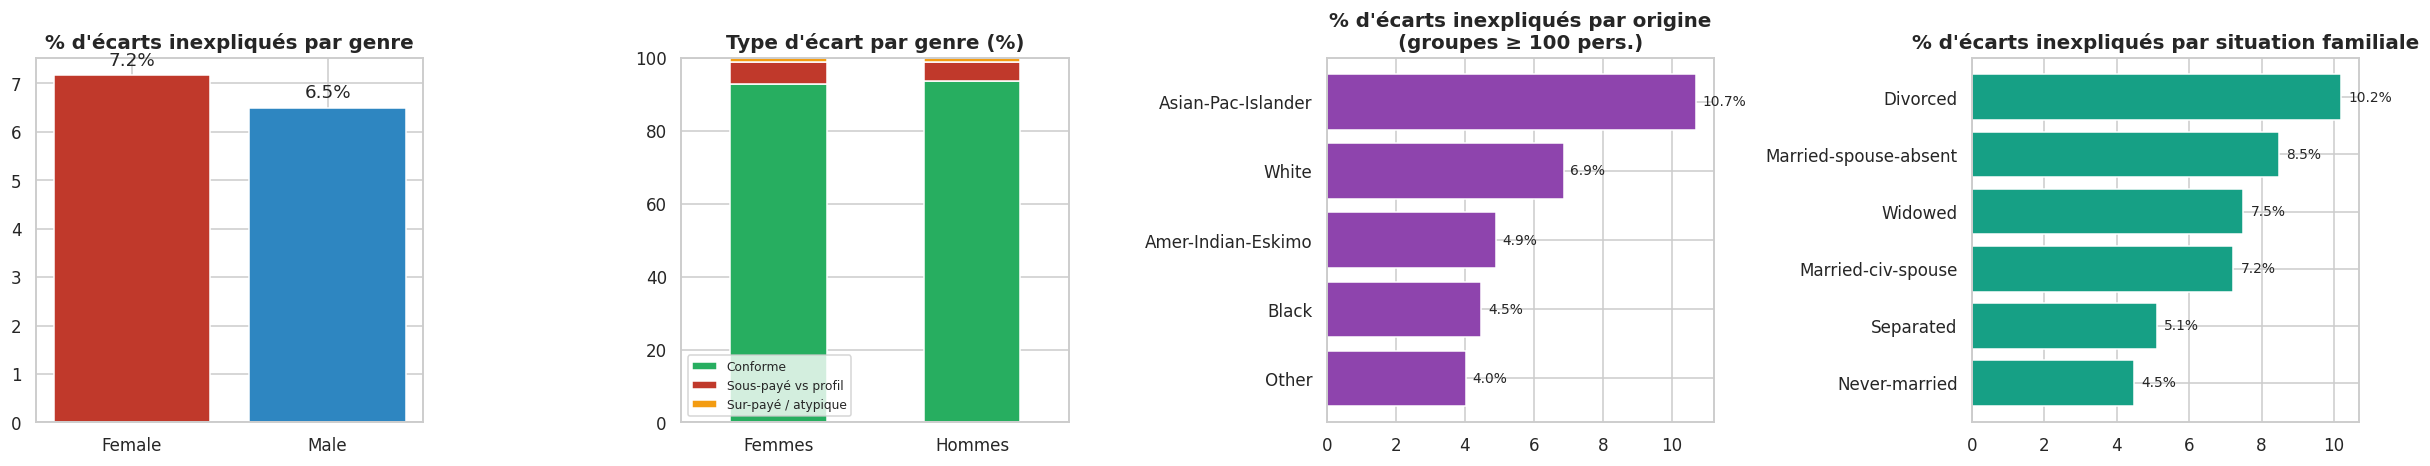

📸 capture enregistrée : captures/20_audit_equite_genre_race.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.4))
g = df_clean.groupby("sex")["target"].mean() * 100
axes[0].bar(g.index, g.values, color=["#C0392B", "#2E86C1"]); axes[0].set_title("% d'écarts inexpliqués par genre")
for i, v in enumerate(g.values): axes[0].text(i, v + 0.2, f"{v:.1f}%", ha="center")

g2 = df_clean[df_clean["sex"] == "Female"].groupby("type_ecart").size() / (df_clean["sex"] == "Female").sum() * 100
g3 = df_clean[df_clean["sex"] == "Male"].groupby("type_ecart").size() / (df_clean["sex"] == "Male").sum() * 100
ct = pd.DataFrame({"Femmes": g2, "Hommes": g3}).fillna(0).T[["Conforme", "Sous-payé vs profil", "Sur-payé / atypique"]]
ct.plot(kind="bar", stacked=True, ax=axes[1], color=["#27AE60", "#C0392B", "#F39C12"], rot=0)
axes[1].set_title("Type d'écart par genre (%)"); axes[1].legend(fontsize=8, loc="lower left"); axes[1].set_ylim(0, 100)

r = (df_clean.groupby("race")["target"].agg(["mean", "size"]))
r = r[r["size"] >= 100].sort_values("mean")
axes[2].barh(r.index, r["mean"] * 100, color="#8E44AD"); axes[2].set_title("% d'écarts inexpliqués par origine\n(groupes ≥ 100 pers.)")
for i, v in enumerate(r["mean"].values * 100): axes[2].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
m = df_clean.groupby("marital-status")["target"].agg(["mean", "size"]); m = m[m["size"] >= 100].sort_values("mean")
axes[3].barh(m.index, m["mean"] * 100, color="#16A085"); axes[3].set_title("% d'écarts inexpliqués par situation familiale")
for i, v in enumerate(m["mean"].values * 100): axes[3].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout(); save_fig("20_audit_equite_genre_race")

---
# ÉTAPE 4 — Transformation des données

Pipeline appliqué **uniquement sur les features retenues** :

1. **Séparation train / test (80 / 20, stratifiée)** *avant* toute transformation → évite la fuite de données (*data leakage*).
2. **Variables numériques** → standardisation (`StandardScaler`) : moyenne 0, écart-type 1, ajustée sur le train uniquement.
3. **Variables catégorielles** → encodage *One-Hot* (`handle_unknown="ignore"` pour les catégories inconnues en production).
4. `sex` et `race` sont conservées **à part** (jeu d'audit) pour évaluer l'équité du modèle plus tard.

Numériques : ['education-num', 'age', 'hours-per-week']
Catégorielles : ['occupation']


,Lignes,% target = 1
Train (80 %),24555,6.72
Test (20 %),6139,6.71


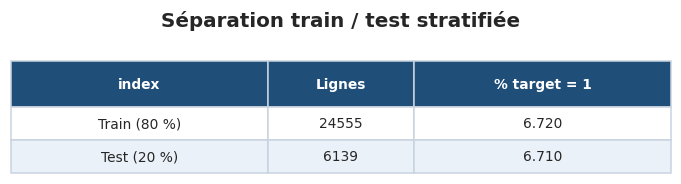

📸 capture enregistrée : captures/21_split_train_test.png


In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

FEATURES = selected
num_f = [c for c in FEATURES if pd.api.types.is_numeric_dtype(df_clean[c])]
cat_f = [c for c in FEATURES if c not in num_f]
print("Numériques :", num_f); print("Catégorielles :", cat_f)

X, y = df_clean[FEATURES], df_clean["target"]
audit = df_clean[["sex", "race"]]

X_train, X_test, y_train, y_test, aud_train, aud_test = train_test_split(
    X, y, audit, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

split = pd.DataFrame({
    "Lignes": [len(X_train), len(X_test)],
    "% target = 1": [y_train.mean() * 100, y_test.mean() * 100],
}, index=["Train (80 %)", "Test (20 %)"]).round(2)
display(split)
save_table(split, "21_split_train_test", title="Séparation train / test stratifiée", index=True)

AVANT : 4 colonnes  →  APRÈS : 17 colonnes

--- AVANT transformation (train) ---


,education-num,occupation,age,hours-per-week
21522,10,Adm-clerical,30,10
30351,10,Adm-clerical,22,20
24304,13,Prof-specialty,46,40
17018,9,Exec-managerial,80,20
21543,9,Handlers-cleaners,25,40


--- APRÈS transformation (train) ---


,education-num,age,hours-per-week,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
21522,-0.047958,-0.644914,-2.652879,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30351,-0.047958,-1.255106,-1.794072,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24304,1.123789,0.575470,-0.076458,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
17018,-0.438540,3.168786,-1.794072,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21543,-0.438540,-1.026284,-0.076458,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


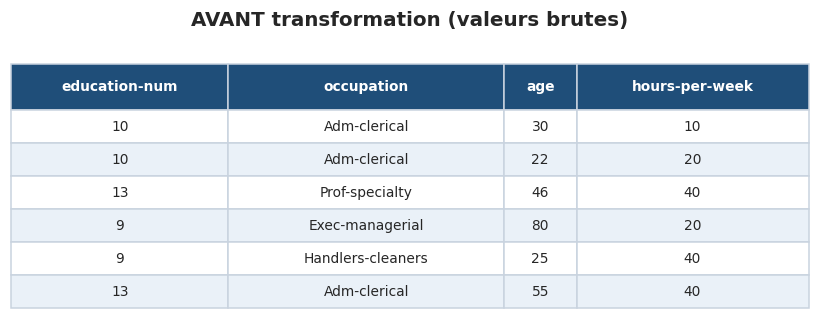

📸 capture enregistrée : captures/22_avant_transformation.png


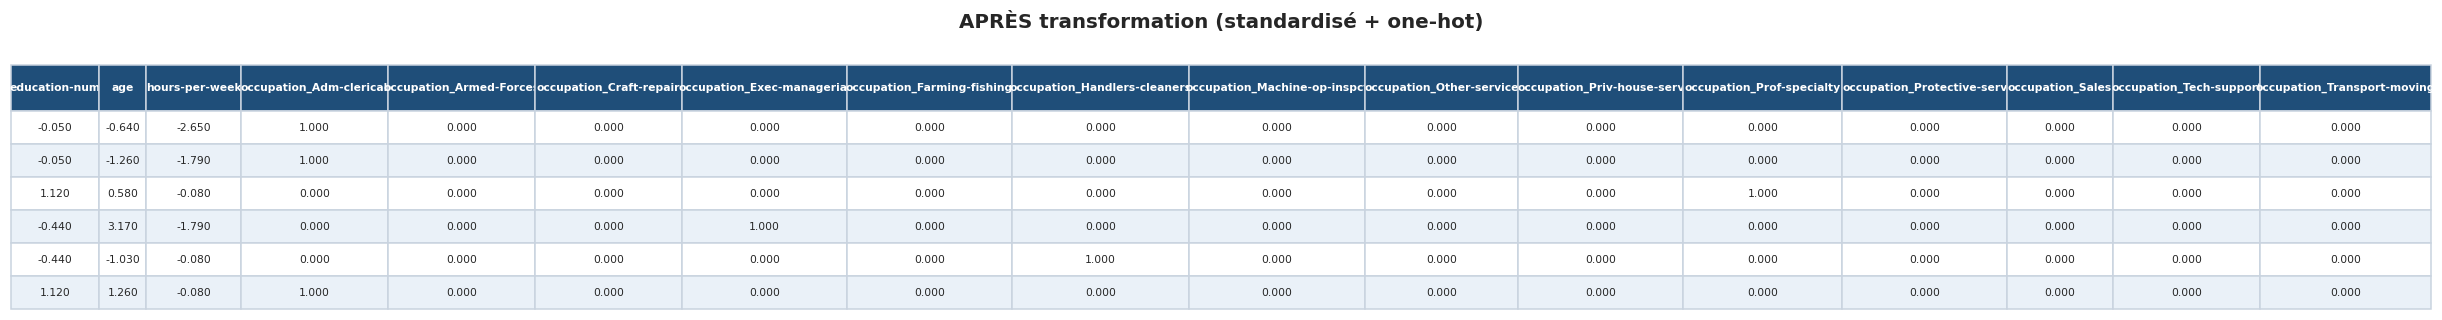

📸 capture enregistrée : captures/23_apres_transformation.png


In [ ]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_f),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_f),
])
Xtr_t = preprocess.fit_transform(X_train)          # fit UNIQUEMENT sur le train
Xte_t = preprocess.transform(X_test)
names = [n.split("__", 1)[1] for n in preprocess.get_feature_names_out()]
Xtr_df = pd.DataFrame(Xtr_t, columns=names, index=X_train.index)
Xte_df = pd.DataFrame(Xte_t, columns=names, index=X_test.index)

print(f"AVANT : {X_train.shape[1]} colonnes  →  APRÈS : {Xtr_df.shape[1]} colonnes")
print("\n--- AVANT transformation (train) ---"); display(X_train.head())
print("--- APRÈS transformation (train) ---"); display(Xtr_df.head())
save_table(X_train.head(6), "22_avant_transformation", title="AVANT transformation (valeurs brutes)")
save_table(Xtr_df.head(6).round(2), "23_apres_transformation", title="APRÈS transformation (standardisé + one-hot)", fs=7)

,Moyenne AVANT,Écart-type AVANT,Moyenne APRÈS,Écart-type APRÈS
education-num,10.123,2.560,0.0,1.0
age,38.455,13.111,0.0,1.0
hours-per-week,40.890,11.644,0.0,1.0


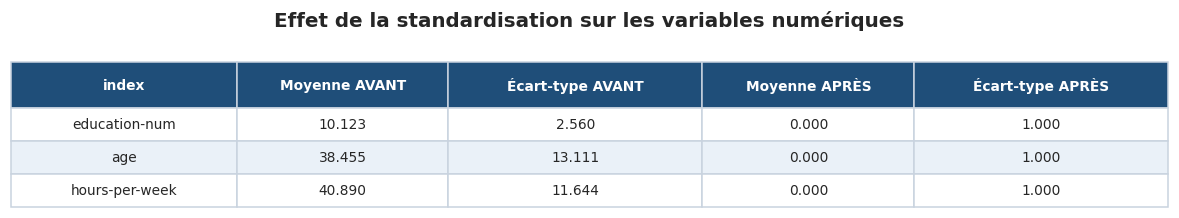

📸 capture enregistrée : captures/24_effet_standardisation.png

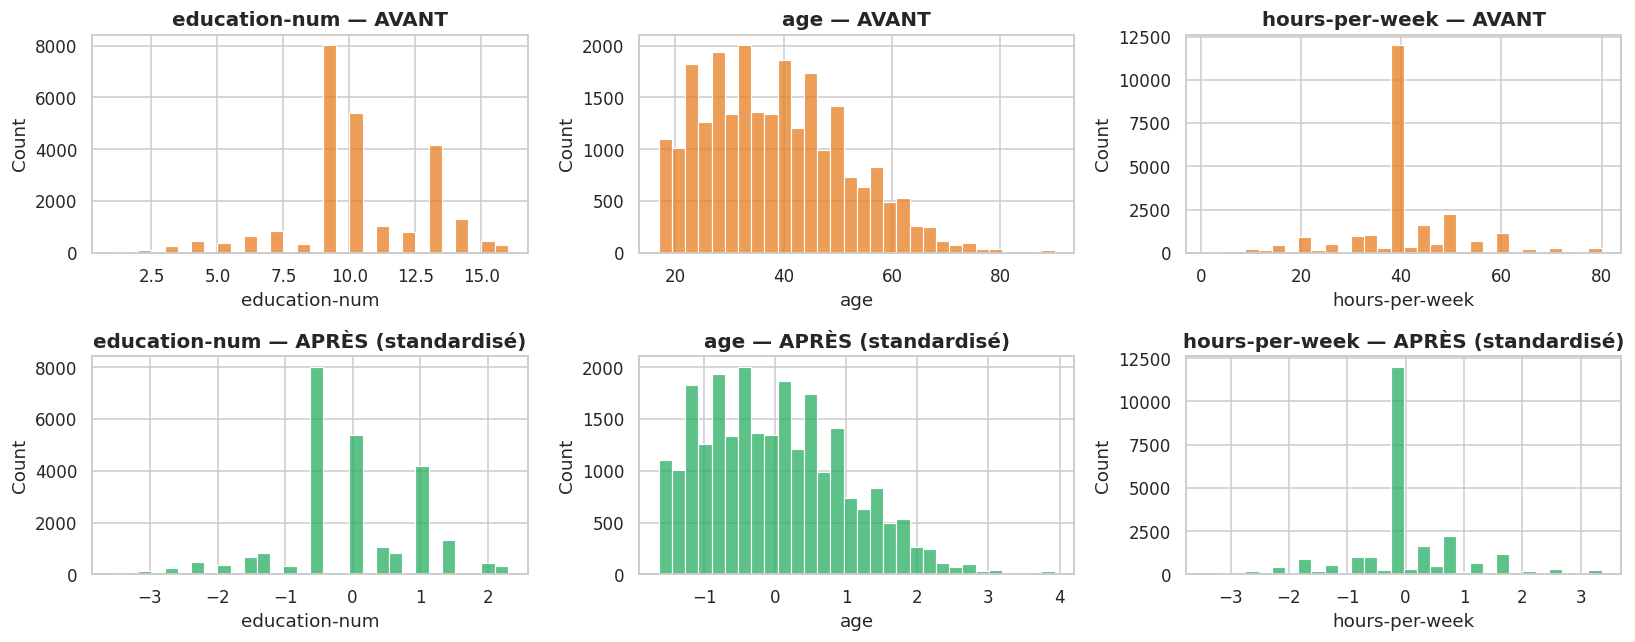

📸 capture enregistrée : captures/25_distributions_avant_apres_scaling.png


In [ ]:
# Effet de la standardisation (variables numériques)
stats = pd.DataFrame({
    "Moyenne AVANT": X_train[num_f].mean(), "Écart-type AVANT": X_train[num_f].std(),
    "Moyenne APRÈS": Xtr_df[num_f].mean(), "Écart-type APRÈS": Xtr_df[num_f].std(),
}).round(3)
display(stats)
save_table(stats, "24_effet_standardisation", title="Effet de la standardisation sur les variables numériques", index=True)

fig, axes = plt.subplots(2, len(num_f), figsize=(5 * len(num_f), 6))
axes = np.atleast_2d(axes)
for j, c in enumerate(num_f):
    sns.histplot(X_train[c], bins=30, ax=axes[0, j], color="#E67E22"); axes[0, j].set_title(f"{c} — AVANT")
    sns.histplot(Xtr_df[c], bins=30, ax=axes[1, j], color="#27AE60"); axes[1, j].set_title(f"{c} — APRÈS (standardisé)")
plt.tight_layout(); save_fig("25_distributions_avant_apres_scaling")

,Étape,Lignes,Colonnes,Contenu
0,Brut (Étape 1),"32,561",15,"15 variables brutes, income ≤/>50K"
1,Nettoyé (Étape 2),"30,694",13,variables utiles + target d'équité
2,Features retenues (Étape 3),"30,694",4,"education-num, occupation, age, hours-per-week"
3,Transformé (Étape 4),"24,555 train + 6,139 test",17,numériques standardisées + one-hot


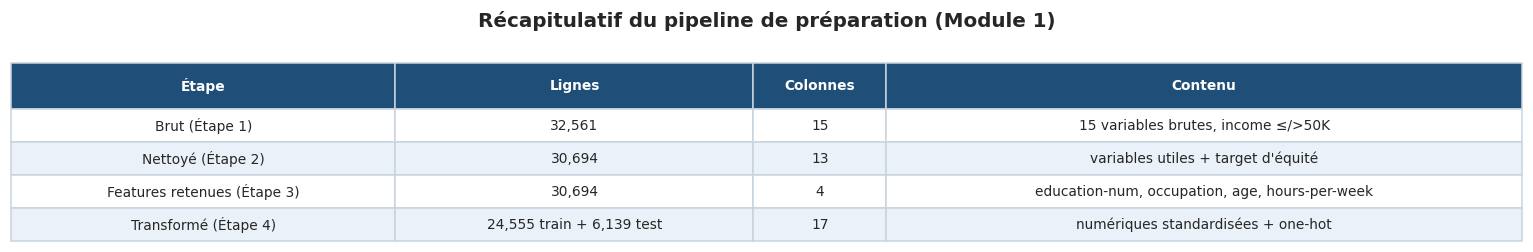

📸 capture enregistrée : captures/26_recap_pipeline.png


In [ ]:
# Sauvegardes pour les étapes de modélisation
Xtr_df.assign(target=y_train.values).to_csv("module1_train_prepared.csv", index=False)
Xte_df.assign(target=y_test.values).to_csv("module1_test_prepared.csv", index=False)
aud_train.to_csv("module1_audit_train.csv", index=False); aud_test.to_csv("module1_audit_test.csv", index=False)
joblib.dump(preprocess, "module1_preprocessor.joblib")

final = pd.DataFrame({
    "Étape": ["Brut (Étape 1)", "Nettoyé (Étape 2)", "Features retenues (Étape 3)", "Transformé (Étape 4)"],
    "Lignes": [f"{len(df_raw):,}", f"{len(df_clean):,}", f"{len(df_clean):,}", f"{len(Xtr_df):,} train + {len(Xte_df):,} test"],
    "Colonnes": [df_raw.shape[1], df_clean.shape[1], len(FEATURES), Xtr_df.shape[1]],
    "Contenu": ["15 variables brutes, income ≤/>50K", "variables utiles + target d'équité",
                ", ".join(FEATURES), "numériques standardisées + one-hot"],
})
display(final)
save_table(final, "26_recap_pipeline", title="Récapitulatif du pipeline de préparation (Module 1)", wrap=48)

---
# ÉTAPE 5 — Segmentation (clustering)

**Objectif :** regrouper les collaborateurs en **profils homogènes** (niveau d'études, âge, heures, poste) pour voir **dans quels segments se concentrent les écarts salariaux inexpliqués**, et si ces segments sont plus ou moins féminins.

**Principes méthodologiques**
- Le clustering est **non supervisé** : il utilise uniquement les features retenues à l'étape 3 (après la transformation de l'étape 4). Ni la target, ni `sex`, ni `race` ne sont utilisées pour former les groupes → les segments ne sont pas biaisés par construction.
- `target`, `sex` et `race` servent seulement à **décrire** les segments une fois formés (profilage).
- **Choix de k** : méthode du coude (inertie) et score de silhouette pour k = 2 à 8. Pour obtenir des segments exploitables par les RH, on retient le k de **3 à 6** qui maximise la silhouette (k = 2 ne ferait que séparer « qualifiés » et « peu qualifiés »).

Silhouette par k : {2: 0.177, 3: 0.199, 4: 0.203, 5: 0.206, 6: 0.206, 7: 0.2, 8: 0.19}
→ k retenu = 6 (meilleure silhouette parmi k = 3..6)


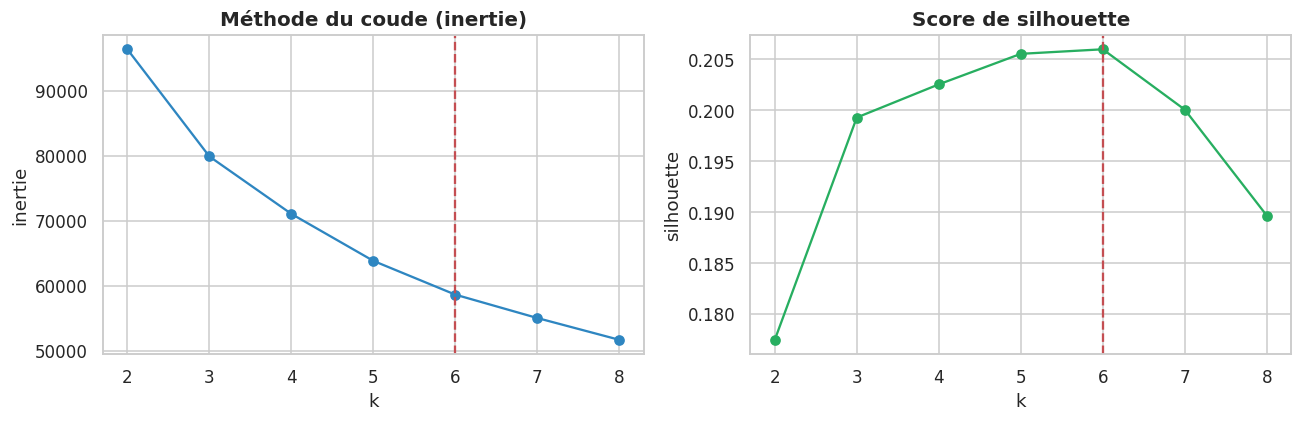

📸 capture enregistrée : captures/27_choix_k_segmentation.png


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X_all = preprocess.transform(df_clean[FEATURES])           # transformation seule (préprocesseur ajusté sur le train)
rng = np.random.RandomState(RANDOM_STATE)
sil_idx = rng.choice(len(X_all), size=min(6000, len(X_all)), replace=False)   # échantillon pour la silhouette (rapide)

ks = list(range(2, 9))
inertia, sil = [], []
for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_all)
    inertia.append(km_k.inertia_)
    sil.append(silhouette_score(X_all[sil_idx], km_k.labels_[sil_idx]))

cand = [(k, s) for k, s in zip(ks, sil) if 3 <= k <= 6]
K_SEG = max(cand, key=lambda t: t[1])[0]
print(f"Silhouette par k : { {k: round(s, 3) for k, s in zip(ks, sil)} }")
print(f"→ k retenu = {K_SEG} (meilleure silhouette parmi k = 3..6)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertia, "o-", color="#2E86C1"); axes[0].axvline(K_SEG, ls="--", c="r")
axes[0].set_title("Méthode du coude (inertie)"); axes[0].set_xlabel("k"); axes[0].set_ylabel("inertie")
axes[1].plot(ks, sil, "o-", color="#27AE60"); axes[1].axvline(K_SEG, ls="--", c="r")
axes[1].set_title("Score de silhouette"); axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")
plt.tight_layout(); save_fig("27_choix_k_segmentation")

,Effectif,Âge moyen,Études (1-16),Heures/sem.,Profession dominante,% femmes,% revenu >50K,% écart inexpliqué,% sous-payé
S0,10052,30.6,9.3,41.3,Craft-repair,31.8,12.5,2.0,0.1
S1,2817,40.7,10.7,63.4,Exec-managerial,14.5,40.2,13.1,12.7
S2,2932,24.1,9.5,20.4,Other-service,55.5,2.6,0.8,0.1
S3,2030,45.6,4.5,39.3,Craft-repair,26.2,7.6,2.6,0.0
S4,6017,54.6,9.8,37.8,Adm-clerical,34.3,28.9,4.8,3.9
S5,6846,38.9,13.4,42.9,Prof-specialty,30.5,48.1,16.4,15.8


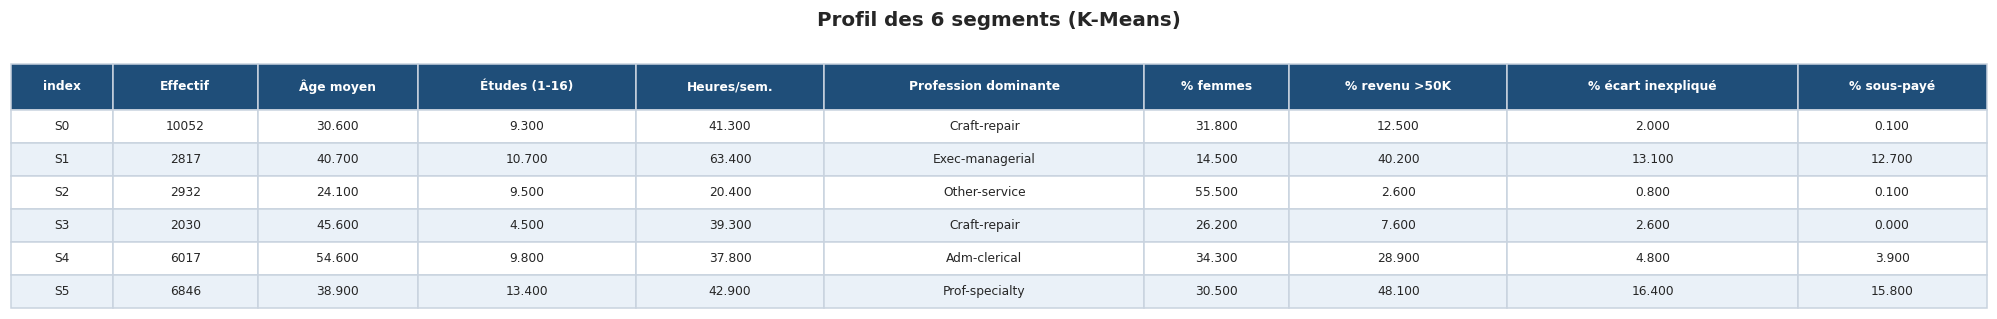

📸 capture enregistrée : captures/28_profil_segments.png


In [ ]:
km = KMeans(n_clusters=K_SEG, n_init=20, random_state=RANDOM_STATE).fit(X_all)
seg = df_clean.copy()
seg["segment"] = km.labels_

def top_occ(s):
    return s.value_counts().index[0]

prof = seg.groupby("segment").agg(
    Effectif=("target", "size"),
    Age_moyen=("age", "mean"),
    Etudes_moy=("education-num", "mean"),
    Heures_moy=("hours-per-week", "mean"),
    Profession_dominante=("occupation", top_occ),
    Pct_femmes=("sex", lambda s: (s == "Female").mean() * 100),
    Pct_revenu_sup_50K=("income_bin", lambda s: s.mean() * 100),
    Pct_ecart_inexplique=("target", lambda s: s.mean() * 100),
    Pct_sous_paye=("type_ecart", lambda s: (s == "Sous-payé vs profil").mean() * 100),
).round(1)
prof.index = [f"S{i}" for i in prof.index]
prof.columns = ["Effectif", "Âge moyen", "Études (1-16)", "Heures/sem.", "Profession dominante",
                "% femmes", "% revenu >50K", "% écart inexpliqué", "% sous-payé"]
display(prof)
save_table(prof, "28_profil_segments", title=f"Profil des {K_SEG} segments (K-Means)", index=True, wrap=22, fs=8)

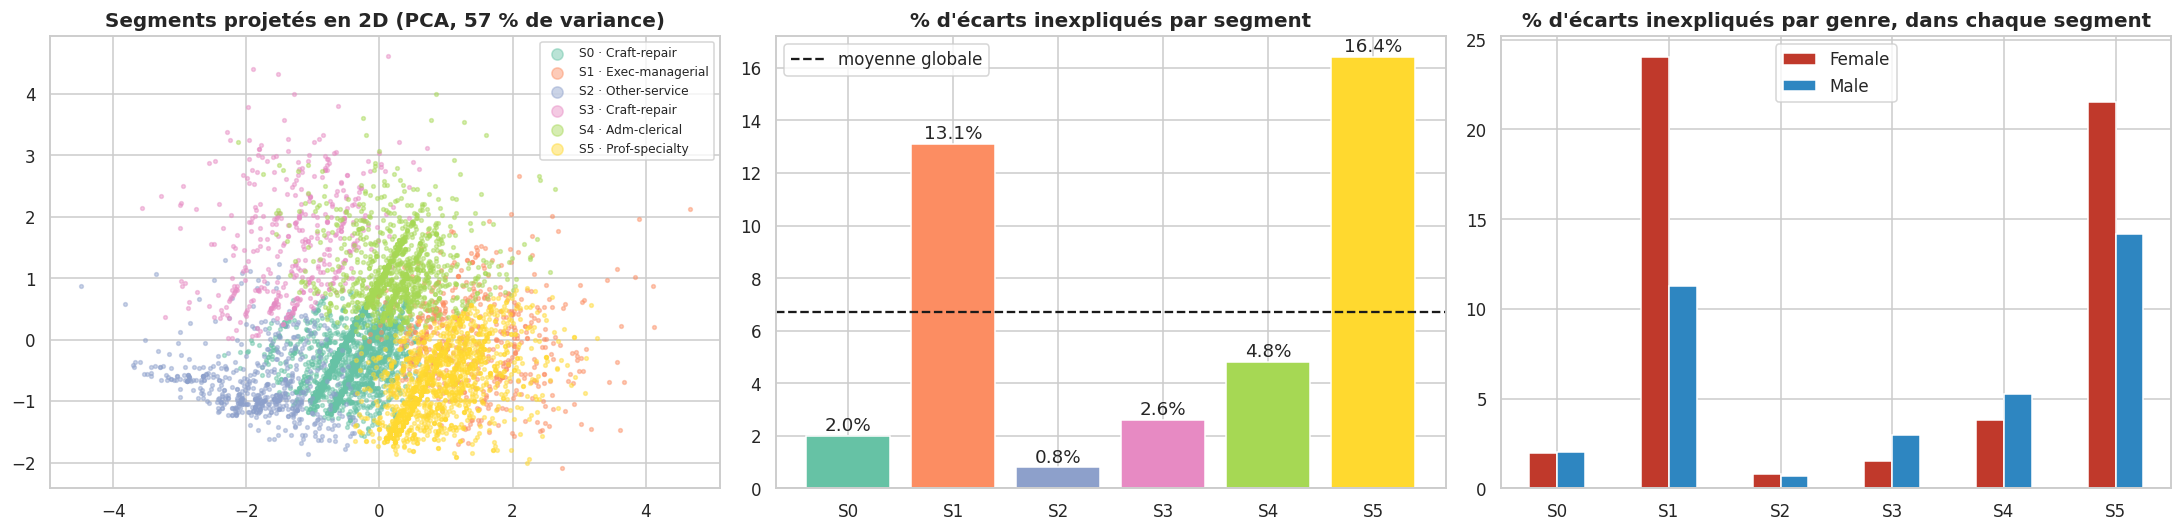

📸 capture enregistrée : captures/29_segments_pca_ecarts_genre.png
→ Segment le plus exposé : S5 (16.4 % d'écarts inexpliqués ; profession dominante : Prof-specialty).
→ Segment le moins exposé : S2 (0.8 %).
→ S1 : les femmes ont plus d'écarts inexpliqués que les hommes (24.0 % vs 11.3 %, +12.7 pts).
→ S5 : les femmes ont plus d'écarts inexpliqués que les hommes (21.5 % vs 14.2 %, +7.3 pts).


In [ ]:
seg["seg_lbl"] = "S" + seg["segment"].astype(str)
order = list(prof.index)
palette = sns.color_palette("Set2", K_SEG)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (a) projection PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_all)
Z = pca.transform(X_all[sil_idx])
for i, lbl in enumerate(order):
    m = (km.labels_[sil_idx] == i)
    axes[0].scatter(Z[m, 0], Z[m, 1], s=6, alpha=.45, color=palette[i], label=f"{lbl} · {prof.loc[lbl, 'Profession dominante']}")
axes[0].set_title(f"Segments projetés en 2D (PCA, {pca.explained_variance_ratio_.sum()*100:.0f} % de variance)")
axes[0].legend(markerscale=3, fontsize=8)

# (b) taux d'écart inexpliqué par segment
vals = prof["% écart inexpliqué"]
axes[1].bar(order, vals.values, color=palette)
axes[1].axhline(df_clean["target"].mean() * 100, ls="--", c="k", label="moyenne globale")
for i, v in enumerate(vals.values): axes[1].text(i, v + 0.2, f"{v:.1f}%", ha="center")
axes[1].set_title("% d'écarts inexpliqués par segment"); axes[1].legend()

# (c) écart par genre à l'intérieur de chaque segment
gs = seg.groupby(["seg_lbl", "sex"])["target"].mean().unstack() * 100
gs = gs.loc[order]
gs.plot(kind="bar", ax=axes[2], color=["#C0392B", "#2E86C1"], rot=0)
axes[2].set_title("% d'écarts inexpliqués par genre, dans chaque segment"); axes[2].set_xlabel(""); axes[2].legend(title="", loc="upper center")
plt.tight_layout(); save_fig("29_segments_pca_ecarts_genre")

worst = vals.idxmax(); best = vals.idxmin()
print(f"→ Segment le plus exposé : {worst} ({vals[worst]:.1f} % d'écarts inexpliqués ; profession dominante : {prof.loc[worst, 'Profession dominante']}).")
print(f"→ Segment le moins exposé : {best} ({vals[best]:.1f} %).")
gap = (gs["Female"] - gs["Male"]).round(1)
for s_ in gap.index:
    if abs(gap[s_]) >= 2:
        sens = "plus" if gap[s_] > 0 else "moins"
        print(f"→ {s_} : les femmes ont {sens} d'écarts inexpliqués que les hommes ({gs.loc[s_, 'Female']:.1f} % vs {gs.loc[s_, 'Male']:.1f} %, {gap[s_]:+.1f} pts).")

---
# ÉTAPE 6 — Classification supervisée

**Objectif :** entraîner un modèle qui **détecte les collaborateurs dont la rémunération présente un écart inexpliqué** (`target = 1`) à partir des seules features retenues (`education-num`, `occupation`, `age`, `hours-per-week`). Les attributs sensibles ne sont **jamais** donnés au modèle.

**Démarche**
1. **Comparaison de 4 modèles** en validation croisée 5 plis sur le **train uniquement** : baseline (prédit toujours la prévalence), régression logistique, Random Forest, Gradient Boosting.
2. **Déséquilibre de classes** : la target = 1 est rare → `class_weight` équilibré, et métriques adaptées (**PR-AUC / average precision**, rappel, F1) plutôt que l'accuracy, qui serait trompeuse.
3. **Réglage des hyperparamètres** (`GridSearchCV`, critère = PR-AUC) pour chaque modèle.
4. **Choix du seuil de décision** sur les prédictions out-of-fold du train (maximise le F1) : le test reste intact jusqu'à l'étape 7.

> ⚠ **Point d'attention :** la target dépend du revenu réel (`income`) que le modèle **ne voit pas**. Le modèle peut donc apprendre *quels profils* sont susceptibles d'écart, mais pas deviner le revenu réel : les performances sont naturellement bornées, ce qui est cohérent avec un outil de **détection de risque** à investiguer, pas un verdict.

Prévalence de target = 1 dans le train : 6.7 %


,ROC-AUC,PR-AUC,"F1 (seuil 0,5)","Rappel (seuil 0,5)"
Modèle,,,,
Baseline (prévalence),0.500,0.067,0.00,0.000
Régression logistique,0.812,0.221,0.30,0.821
Random Forest,0.873,0.314,0.40,0.751
Gradient Boosting,0.852,0.272,0.38,0.764


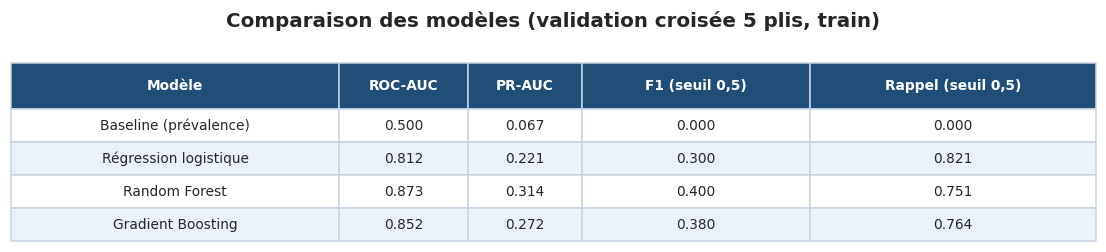

📸 capture enregistrée : captures/30_comparaison_modeles_cv.png


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, precision_recall_curve, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
prevalence = y_train.mean()
print(f"Prévalence de target = 1 dans le train : {prevalence*100:.1f} %")

models = {
    "Baseline (prévalence)": DummyClassifier(strategy="prior"),
    "Régression logistique": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=10, class_weight="balanced_subsample",
                                            n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": HistGradientBoostingClassifier(max_depth=4, class_weight="balanced", random_state=RANDOM_STATE),
}
rows = []
for name, mdl in models.items():
    r = cross_validate(mdl, Xtr_df, y_train, cv=cv5, n_jobs=-1,
                       scoring={"auc": "roc_auc", "pr": "average_precision", "f1": "f1", "rec": "recall"})
    rows.append([name, r["test_auc"].mean(), r["test_pr"].mean(), r["test_f1"].mean(), r["test_rec"].mean()])
cmp_cv = pd.DataFrame(rows, columns=["Modèle", "ROC-AUC", "PR-AUC", "F1 (seuil 0,5)", "Rappel (seuil 0,5)"]).set_index("Modèle").round(3)
display(cmp_cv)
save_table(cmp_cv, "30_comparaison_modeles_cv", title="Comparaison des modèles (validation croisée 5 plis, train)", index=True)

,Modèle,Meilleurs hyperparamètres,PR-AUC (CV)
1,Random Forest,"{'max_depth': 14, 'min_samples_leaf': 20}",0.3112
2,Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.2968
0,Régression logistique,{'C': 10},0.2212


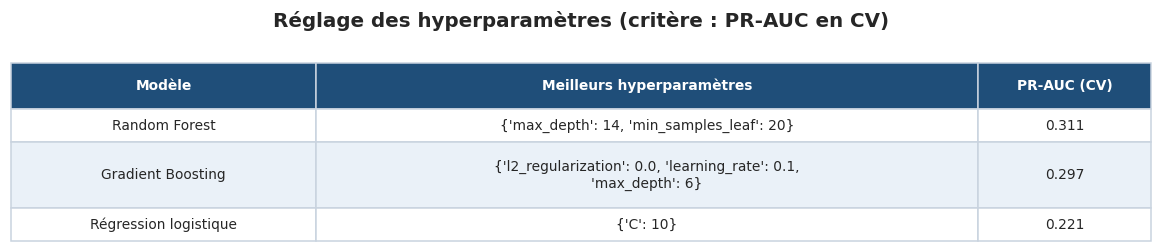

📸 capture enregistrée : captures/31_reglage_hyperparametres.png

🏆 Modèle retenu : Random Forest


In [ ]:
grids = {
    "Régression logistique": (LogisticRegression(max_iter=2000, class_weight="balanced"),
                              {"C": [0.01, 0.1, 1, 10]}),
    "Random Forest": (RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE),
                      {"max_depth": [6, 10, 14], "min_samples_leaf": [5, 20, 50]}),
    "Gradient Boosting": (HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
                          {"max_depth": [3, 4, 6], "learning_rate": [0.03, 0.1], "l2_regularization": [0.0, 1.0]}),
}
tuned, tune_rows = {}, []
for name, (est, grid) in grids.items():
    gs_ = GridSearchCV(est, grid, scoring="average_precision", cv=cv5, n_jobs=-1).fit(Xtr_df, y_train)
    tuned[name] = gs_.best_estimator_
    tune_rows.append([name, str(gs_.best_params_), round(gs_.best_score_, 4)])

tune_df = pd.DataFrame(tune_rows, columns=["Modèle", "Meilleurs hyperparamètres", "PR-AUC (CV)"]).sort_values("PR-AUC (CV)", ascending=False)
display(tune_df)
save_table(tune_df, "31_reglage_hyperparametres", title="Réglage des hyperparamètres (critère : PR-AUC en CV)", wrap=50)

best_name = tune_df.iloc[0]["Modèle"]
best_model = tuned[best_name]
print(f"\n🏆 Modèle retenu : {best_name}")

Seuil optimal (max F1 sur train, out-of-fold) : 0.731   (F1 = 0.426)


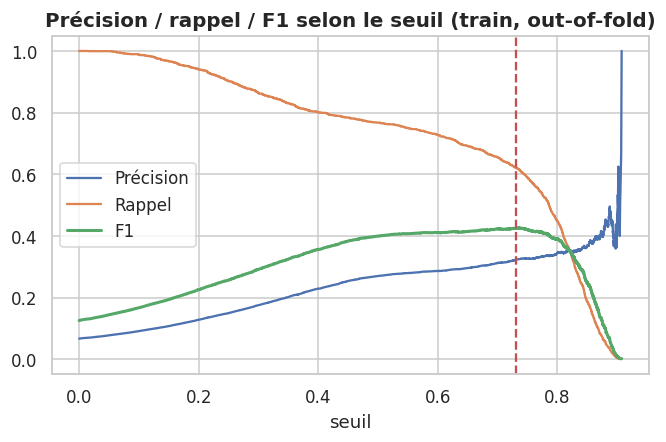

📸 capture enregistrée : captures/32_choix_du_seuil.png


In [ ]:
# Seuil de décision choisi sur les prédictions out-of-fold du TRAIN (le test n'est pas utilisé)
oof = cross_val_predict(best_model, Xtr_df, y_train, cv=cv5, method="predict_proba", n_jobs=-1)[:, 1]
prec_c, rec_c, thr_c = precision_recall_curve(y_train, oof)
f1_c = 2 * prec_c[:-1] * rec_c[:-1] / np.clip(prec_c[:-1] + rec_c[:-1], 1e-9, None)
THRESHOLD = float(thr_c[np.argmax(f1_c)])
print(f"Seuil optimal (max F1 sur train, out-of-fold) : {THRESHOLD:.3f}   (F1 = {f1_c.max():.3f})")

best_model.fit(Xtr_df, y_train)          # modèle final entraîné sur tout le train

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thr_c, prec_c[:-1], label="Précision"); ax.plot(thr_c, rec_c[:-1], label="Rappel"); ax.plot(thr_c, f1_c, label="F1", lw=2)
ax.axvline(THRESHOLD, ls="--", c="r"); ax.set_xlabel("seuil"); ax.set_title("Précision / rappel / F1 selon le seuil (train, out-of-fold)"); ax.legend()
save_fig("32_choix_du_seuil")

---
# ÉTAPE 7 — Évaluation et interprétation des résultats

L'évaluation se fait **une seule fois, sur le jeu de test** (jamais vu pendant l'entraînement, le réglage ni le choix du seuil).

| Section | Question à laquelle on répond |
|---|---|
| 7.1 Performance | Le modèle détecte-t-il mieux que le hasard ? |
| 7.2 Courbes et matrice de confusion | Quels types d'erreurs fait-il ? |
| 7.3 Importance des variables | Qu'est-ce qui explique ses décisions ? |
| 7.4 Audit d'équité | Les écarts touchent-ils davantage certains groupes ? Le modèle traite-t-il les groupes de façon équitable ? |
| 7.5 Synthèse et limites | Que conclure, et avec quelles précautions ? |

## 7.1 Performance sur le jeu de test

,Accuracy,Précision,Rappel,F1,ROC-AUC,PR-AUC
"Seuil 0,5",0.840,0.259,0.748,0.385,0.86,0.296
Seuil optimisé (0.73),0.882,0.307,0.609,0.408,0.86,0.296


Repère : un modèle aléatoire aurait ROC-AUC = 0,50 et PR-AUC ≈ 0.067 (la prévalence). Gain de PR-AUC vs hasard : ×4.4


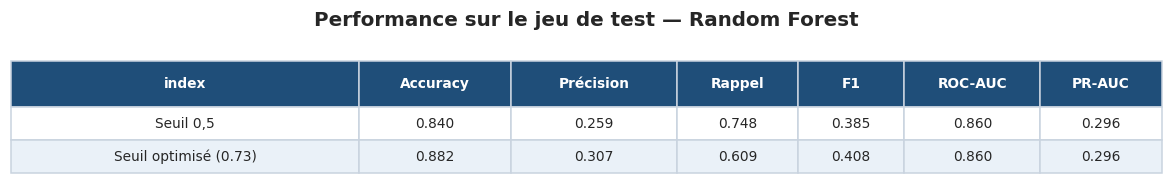

📸 capture enregistrée : captures/33_performance_test.png


In [ ]:
proba_te = best_model.predict_proba(Xte_df)[:, 1]
yt = y_test.values

def metrics_at(thr):
    p = (proba_te >= thr).astype(int)
    return [accuracy_score(yt, p), precision_score(yt, p, zero_division=0), recall_score(yt, p), f1_score(yt, p)]

perf = pd.DataFrame(
    [metrics_at(0.5) + [roc_auc_score(yt, proba_te), average_precision_score(yt, proba_te)],
     metrics_at(THRESHOLD) + [roc_auc_score(yt, proba_te), average_precision_score(yt, proba_te)]],
    columns=["Accuracy", "Précision", "Rappel", "F1", "ROC-AUC", "PR-AUC"],
    index=["Seuil 0,5", f"Seuil optimisé ({THRESHOLD:.2f})"]).round(3)
display(perf)
base_pr = yt.mean()
print(f"Repère : un modèle aléatoire aurait ROC-AUC = 0,50 et PR-AUC ≈ {base_pr:.3f} (la prévalence). "
      f"Gain de PR-AUC vs hasard : ×{perf['PR-AUC'].iloc[0] / base_pr:.1f}")
save_table(perf, "33_performance_test", title=f"Performance sur le jeu de test — {best_name}", index=True)

pred = (proba_te >= THRESHOLD).astype(int)

## 7.2 Matrice de confusion, courbes ROC et précision-rappel

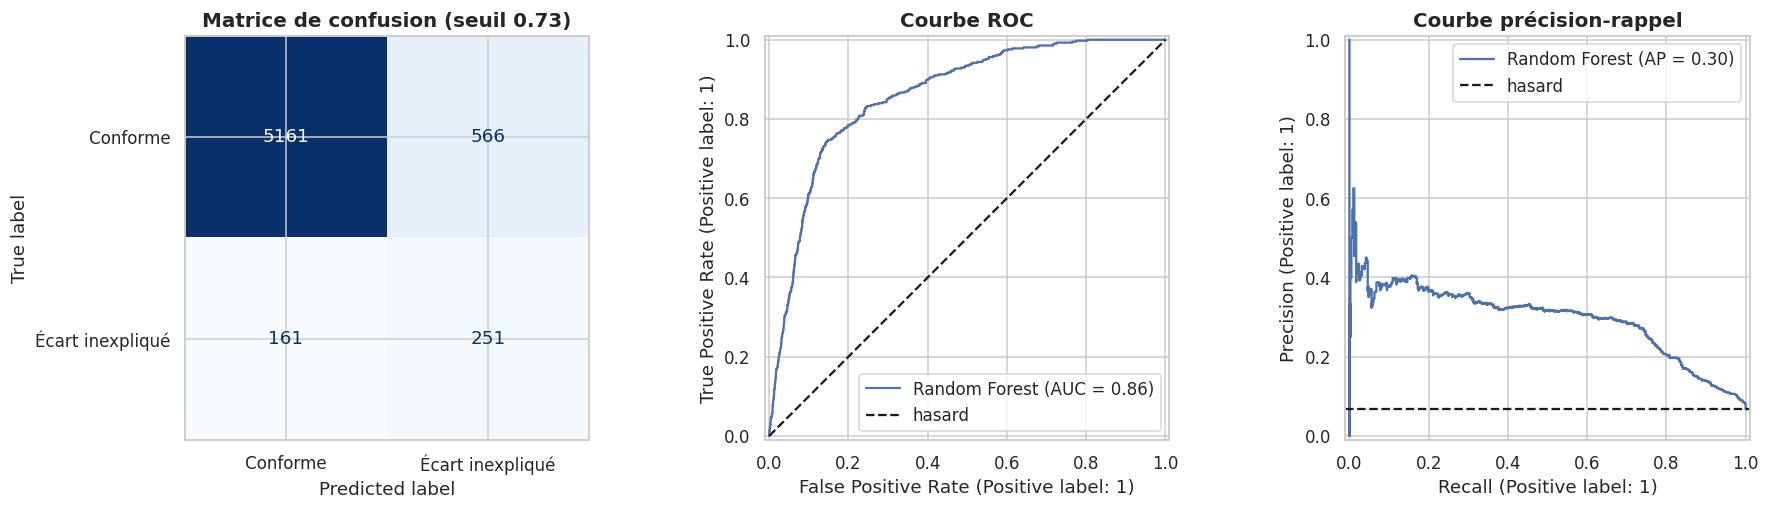

📸 capture enregistrée : captures/34_confusion_roc_pr.png
Vrais positifs : 251  |  Faux positifs : 566  |  Faux négatifs : 161  |  Vrais négatifs : 5161
→ Sur 412 vrais écarts inexpliqués, le modèle en détecte 251 (61 %). Sur 817 alertes émises, 251 sont justifiées (31 %) : les autres sont des cas à vérifier.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
ConfusionMatrixDisplay.from_predictions(yt, pred, display_labels=["Conforme", "Écart inexpliqué"], cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title(f"Matrice de confusion (seuil {THRESHOLD:.2f})")
RocCurveDisplay.from_predictions(yt, proba_te, ax=axes[1], name=best_name); axes[1].plot([0, 1], [0, 1], "k--", label="hasard"); axes[1].legend()
axes[1].set_title("Courbe ROC")
PrecisionRecallDisplay.from_predictions(yt, proba_te, ax=axes[2], name=best_name); axes[2].axhline(base_pr, ls="--", c="k", label="hasard")
axes[2].legend(); axes[2].set_title("Courbe précision-rappel")
plt.tight_layout(); save_fig("34_confusion_roc_pr")

tn, fp, fn, tp = confusion_matrix(yt, pred).ravel()
print(f"Vrais positifs : {tp}  |  Faux positifs : {fp}  |  Faux négatifs : {fn}  |  Vrais négatifs : {tn}")
print(f"→ Sur {tp + fn} vrais écarts inexpliqués, le modèle en détecte {tp} ({tp/(tp+fn)*100:.0f} %). "
      f"Sur {tp + fp} alertes émises, {tp} sont justifiées ({tp/max(tp+fp,1)*100:.0f} %) : les autres sont des cas à vérifier.")

## 7.3 Importance des variables (interprétabilité)
Importance par **permutation** sur le jeu de test et sur les **variables d'origine** (la chute de PR-AUC quand on mélange aléatoirement une colonne mesure sa contribution réelle ; le one-hot de `occupation` est ainsi regroupé en une seule variable).

,Importance (chute de PR-AUC),Écart-type
education-num,0.1680,0.0056
age,0.1207,0.0065
occupation,0.0921,0.0071
hours-per-week,0.0691,0.0101


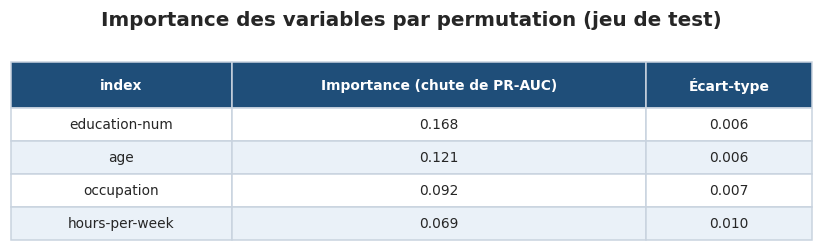

📸 capture enregistrée : captures/35_importance_variables_table.png


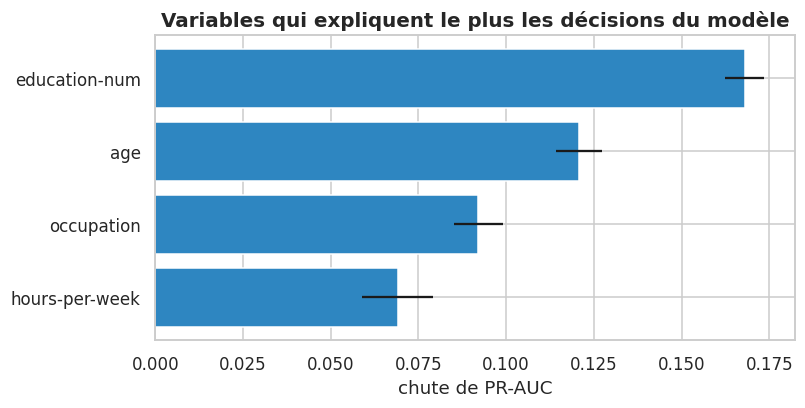

📸 capture enregistrée : captures/36_importance_variables.png
→ Variable la plus déterminante : education-num.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

full_model = Pipeline([("prep", preprocess), ("clf", best_model)])
pi = permutation_importance(full_model, X_test, y_test, scoring="average_precision", n_repeats=10,
                            random_state=RANDOM_STATE, n_jobs=1)
imp = pd.DataFrame({"Importance (chute de PR-AUC)": pi.importances_mean, "Écart-type": pi.importances_std},
                   index=X_test.columns).sort_values("Importance (chute de PR-AUC)", ascending=False).round(4)
display(imp)
save_table(imp, "35_importance_variables_table", title="Importance des variables par permutation (jeu de test)", index=True)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(imp.index[::-1], imp["Importance (chute de PR-AUC)"][::-1], xerr=imp["Écart-type"][::-1], color="#2E86C1")
ax.set_title("Variables qui expliquent le plus les décisions du modèle"); ax.set_xlabel("chute de PR-AUC")
save_fig("36_importance_variables")
print(f"→ Variable la plus déterminante : {imp.index[0]}.")

## 7.4 Audit d'équité
Deux questions distinctes :
1. **Au niveau des données** : les écarts inexpliqués touchent-ils davantage les femmes (ou certaines origines) ? C'est le constat que doit produire le détecteur.
2. **Au niveau du modèle** : le modèle, qui ne voit ni `sex` ni `race`, traite-t-il les groupes équitablement (taux d'alerte, détection, fausses alertes) ? Il pourrait reproduire un biais via des variables proxy (par exemple `occupation`).

> Ici une prédiction positive = « **alerte à investiguer** », pas une sanction. Un taux d'alerte plus élevé pour un groupe n'est donc pas injuste en soi s'il reflète une réalité plus fréquente ; ce sont surtout les écarts de **rappel** (détection) et de **fausses alertes** entre groupes qui signalent un traitement inégal.

,% écart inexpliqué,dont sous-payé vs profil,dont sur-payé / atypique
sex,,,
Female,7.17,5.95,1.22
Male,6.50,5.30,1.19


Test du χ² genre × écart inexpliqué : p = 0.031  |  odds ratio femmes/hommes = 1.11  |  V de Cramér = 0.011


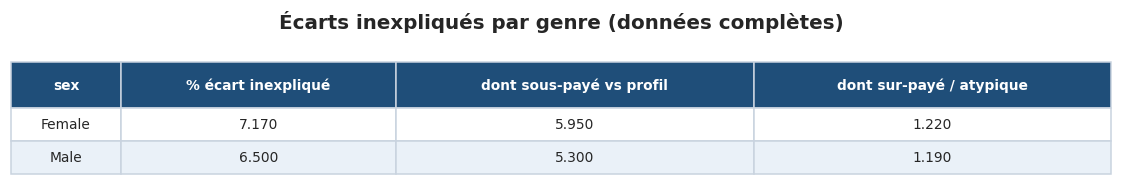

📸 capture enregistrée : captures/37_audit_donnees_genre.png


In [ ]:
from scipy.stats import chi2_contingency

# --- (1) Niveau des données : association entre genre et écart inexpliqué
ct_sex = pd.crosstab(df_clean["sex"], df_clean["target"])
chi2, p_val, _, _ = chi2_contingency(ct_sex)
rate = df_clean.groupby("sex")["target"].mean() * 100
sous_rate = df_clean.groupby("sex")["type_ecart"].apply(lambda s: (s == "Sous-payé vs profil").mean() * 100)
sur_rate = df_clean.groupby("sex")["type_ecart"].apply(lambda s: (s == "Sur-payé / atypique").mean() * 100)
odds = (ct_sex.loc["Female", 1] / ct_sex.loc["Female", 0]) / (ct_sex.loc["Male", 1] / ct_sex.loc["Male", 0])
data_audit = pd.DataFrame({"% écart inexpliqué": rate, "dont sous-payé vs profil": sous_rate, "dont sur-payé / atypique": sur_rate}).round(2)
display(data_audit)
print(f"Test du χ² genre × écart inexpliqué : p = {p_val:.2g}  |  odds ratio femmes/hommes = {odds:.2f}  |  V de Cramér = {cramers_v(df_clean['sex'], df_clean['target']):.3f}")
save_table(data_audit, "37_audit_donnees_genre", title="Écarts inexpliqués par genre (données complètes)", index=True)

,Effectif test,% écart réel,% alertes émises,Rappel (%),Fausses alertes (%),Précision (%)
sex,,,,,,
Male,4177,6.7,15.7,60.0,12.5,25.6
Female,1962,6.7,8.3,62.9,4.3,51.2


,Effectif test,% écart réel,% alertes émises,Rappel (%),Fausses alertes (%),Précision (%)
race,,,,,,
White,5244,6.9,14.1,61.1,10.6,29.7
Black,570,4.7,6.1,59.3,3.5,45.7
Asian-Pac-Islander,200,9.5,15.5,52.6,11.6,32.3
Amer-Indian-Eskimo,74,6.8,9.5,80.0,4.3,57.1
Other,51,2.0,7.8,100.0,6.0,25.0


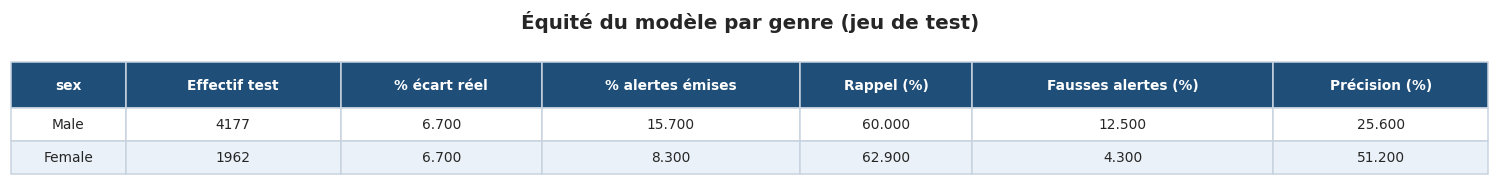

📸 capture enregistrée : captures/38_equite_modele_genre.png


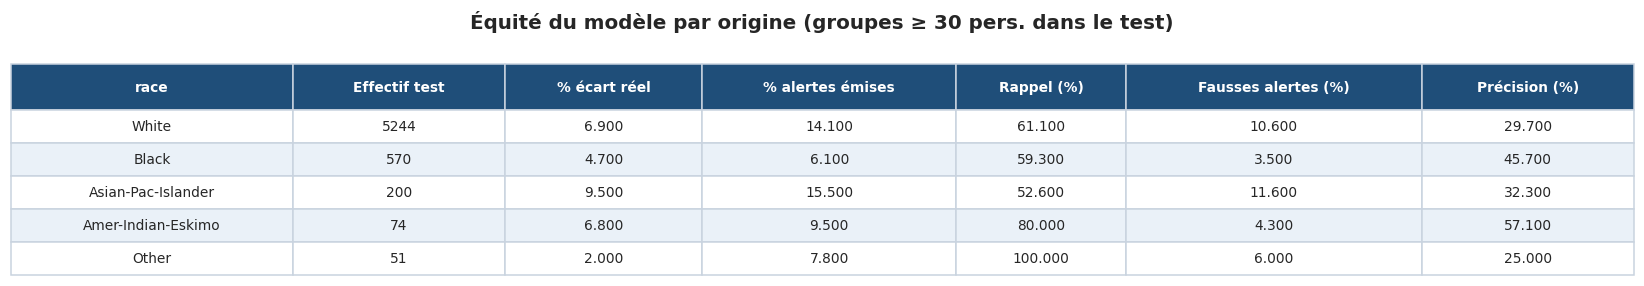

📸 capture enregistrée : captures/39_equite_modele_race.png


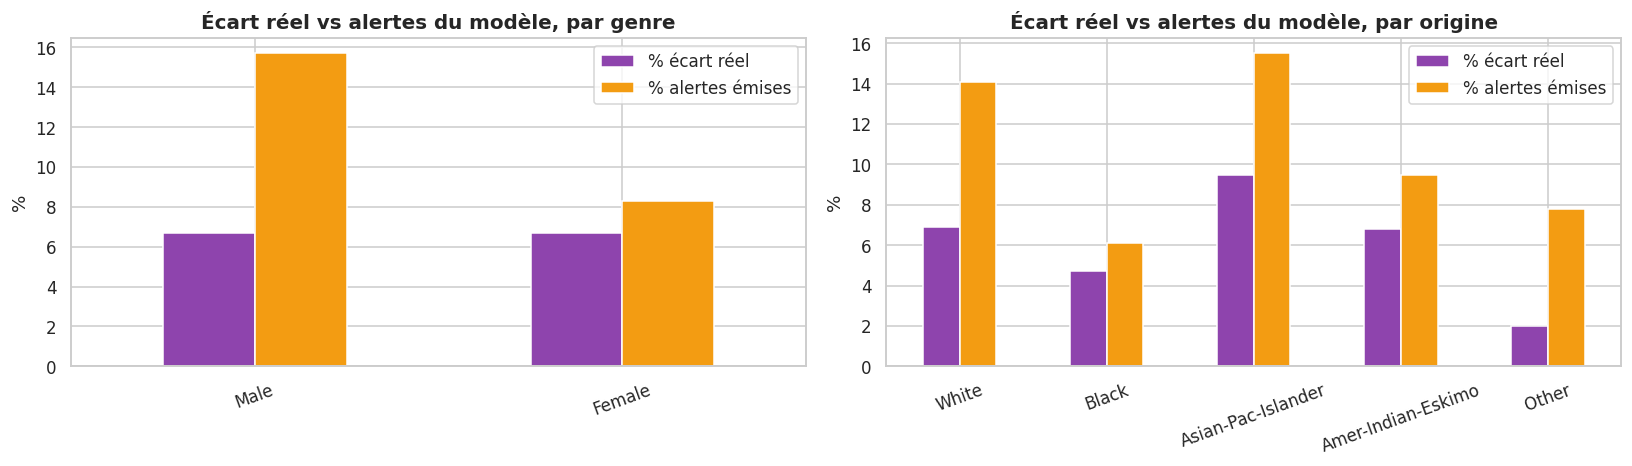

📸 capture enregistrée : captures/40_equite_modele_graphique.png
Parité démographique (genre) : ratio des taux d'alerte = 0.53  (règle des 80 % : non respectée)
Écart de rappel F−H = +2.9 pts  |  écart de fausses alertes F−H = -8.2 pts


In [ ]:
# --- (2) Niveau du modèle : équité des prédictions sur le jeu de test
def fairness_table(attr, min_n=50):
    out = []
    vals_ = aud_test[attr].values
    for g in pd.Series(vals_).value_counts().index:
        m = vals_ == g
        if m.sum() < min_n:
            continue
        yt_g, yp_g = yt[m], pred[m]
        out.append([g, int(m.sum()), yt_g.mean() * 100, yp_g.mean() * 100,
                    yp_g[yt_g == 1].mean() * 100 if (yt_g == 1).any() else np.nan,
                    yp_g[yt_g == 0].mean() * 100,
                    yt_g[yp_g == 1].mean() * 100 if yp_g.sum() > 0 else np.nan])
    return pd.DataFrame(out, columns=[attr, "Effectif test", "% écart réel", "% alertes émises",
                                      "Rappel (%)", "Fausses alertes (%)", "Précision (%)"]).set_index(attr).round(1)

fair_sex = fairness_table("sex")
fair_race = fairness_table("race", min_n=30)
display(fair_sex); display(fair_race)
save_table(fair_sex, "38_equite_modele_genre", title="Équité du modèle par genre (jeu de test)", index=True)
save_table(fair_race, "39_equite_modele_race", title="Équité du modèle par origine (groupes ≥ 30 pers. dans le test)", index=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
for ax, tab, ttl in zip(axes, [fair_sex, fair_race], ["genre", "origine"]):
    tab[["% écart réel", "% alertes émises"]].plot(kind="bar", ax=ax, color=["#8E44AD", "#F39C12"], rot=20)
    ax.set_title(f"Écart réel vs alertes du modèle, par {ttl}"); ax.set_xlabel(""); ax.set_ylabel("%")
plt.tight_layout(); save_fig("40_equite_modele_graphique")

f_, m_ = fair_sex.loc["Female"], fair_sex.loc["Male"]
dp_ratio = min(f_["% alertes émises"], m_["% alertes émises"]) / max(f_["% alertes émises"], m_["% alertes émises"])
print(f"Parité démographique (genre) : ratio des taux d'alerte = {dp_ratio:.2f}  (règle des 80 % : {'respectée' if dp_ratio >= 0.8 else 'non respectée'})")
print(f"Écart de rappel F−H = {f_['Rappel (%)'] - m_['Rappel (%)']:+.1f} pts  |  écart de fausses alertes F−H = {f_['Fausses alertes (%)'] - m_['Fausses alertes (%)']:+.1f} pts")

## 7.5 Synthèse, interprétation et limites

In [ ]:
ecart_f, ecart_h = rate["Female"], rate["Male"]
txt = f"""
RÉSULTATS CLÉS
• Modèle retenu : {best_name} — ROC-AUC = {perf['ROC-AUC'].iloc[1]:.2f}, PR-AUC = {perf['PR-AUC'].iloc[1]:.2f} (hasard = {base_pr:.2f}), \
rappel = {perf['Rappel'].iloc[1]*100:.0f} %, précision = {perf['Précision'].iloc[1]*100:.0f} % au seuil {THRESHOLD:.2f}.
• Variable la plus explicative : {imp.index[0]} (puis {imp.index[1]}).
• Segmentation : {K_SEG} profils ; le plus exposé est {worst} ({vals[worst]:.1f} % d'écarts inexpliqués, profession dominante : {prof.loc[worst, 'Profession dominante']}).
• Données : {ecart_f:.1f} % des femmes et {ecart_h:.1f} % des hommes ont un écart inexpliqué (χ² p = {p_val:.2g}, odds ratio F/H = {odds:.2f}).
• Modèle : ratio des taux d'alerte F/H = {dp_ratio:.2f} ; écart de rappel F−H = {f_['Rappel (%)'] - m_['Rappel (%)']:+.1f} pts.
"""
print(txt)


RÉSULTATS CLÉS
• Modèle retenu : Random Forest — ROC-AUC = 0.86, PR-AUC = 0.30 (hasard = 0.07), rappel = 61 %, précision = 31 % au seuil 0.73.
• Variable la plus explicative : education-num (puis age).
• Segmentation : 6 profils ; le plus exposé est S5 (16.4 % d'écarts inexpliqués, profession dominante : Prof-specialty).
• Données : 7.2 % des femmes et 6.5 % des hommes ont un écart inexpliqué (χ² p = 0.031, odds ratio F/H = 1.11).
• Modèle : ratio des taux d'alerte F/H = 0.53 ; écart de rappel F−H = +2.9 pts.



### Comment lire ces résultats
- **Le modèle est un outil de priorisation, pas un juge.** Il signale des profils à examiner par les RH ; chaque alerte nécessite une vérification humaine (primes, ancienneté, performance, négociation, données absentes du dataset).
- **Performance** : comparer toujours à la prévalence (PR-AUC du hasard), pas à l'accuracy, qui serait élevée même pour un modèle qui ne détecte rien (la classe 1 est rare).
- **Équité** : sexe et origine ne sont pas fournis au modèle, mais l'audit vérifie qu'il ne les reconstitue pas via des variables proxy. Un écart de rappel ou de fausses alertes entre groupes est le signal à surveiller.

### Limites assumées
1. **La target est une construction** (modèle de référence + seuils 0,50 et 0,10), pas une vérité terrain : un « écart inexpliqué » est un écart par rapport à ce qu'expliquent seulement 5 variables. Il peut aussi refléter des facteurs absents du dataset.
2. **Dépendance partielle à la construction** : la target est dérivée des mêmes qualifications que les features ; elle dépend aussi du revenu réel que le modèle ne voit pas, ce qui borne la performance mais ne supprime pas totalement la circularité.
3. **Revenu binaire (≤ / > 50K)** : on ne mesure pas un montant de salaire, seulement un franchissement de seuil.
4. **Données de recensement américain (1994)** : un contexte et une époque éloignés d'une entreprise réelle ; à recalibrer sur les données RH de l'organisation avant tout usage.
5. **Tailles de groupes réduites** pour certaines origines : les taux sont à interpréter avec prudence.

### Pistes d'amélioration
Recalibrer sur des données RH réelles (ancienneté, grade, performance), tester des méthodes de correction d'équité (reweighing, seuils par groupe) et suivre la dérive du modèle dans le temps.

In [ ]:
# Sauvegarde des livrables de modélisation
joblib.dump({"preprocess": preprocess, "model": best_model, "threshold": THRESHOLD, "features": FEATURES},
            "module1_classifier.joblib")
scored = X_test.copy()
scored["target_reelle"] = y_test.values
scored["proba_ecart"] = proba_te.round(4)
scored["alerte"] = pred
scored["segment"] = seg.loc[X_test.index, "segment"].values
scored = scored.join(aud_test)
scored.to_csv("module1_test_scored.csv", index=False)
seg[["age", "education-num", "occupation", "hours-per-week", "sex", "race", "target", "segment"]].to_csv("module1_segments.csv", index=False)
print("✔ module1_classifier.joblib, module1_test_scored.csv, module1_segments.csv enregistrés")
display(scored.head())

✔ module1_classifier.joblib, module1_test_scored.csv, module1_segments.csv enregistrés


,education-num,occupation,age,hours-per-week,target_reelle,proba_ecart,alerte,segment,sex,race
21294,7,Sales,17,16,0,0.0029,0,2,Female,White
5009,9,Sales,43,40,0,0.0987,0,4,Male,White
22141,10,Adm-clerical,23,40,0,0.2337,0,0,Female,White
25192,9,Prof-specialty,70,20,0,0.1120,0,4,Male,White
10867,9,Other-service,30,72,0,0.2739,0,1,Female,White


## Export des captures et fichiers

In [ ]:
shutil.make_archive("captures_module1", "zip", CAP)
print("📦 captures_module1.zip :", len(os.listdir(CAP)), "images")
print(sorted(os.listdir(CAP)))
try:
    from google.colab import files
    files.download("captures_module1.zip")
    for f in ["adult_module1_clean.csv", "module1_train_prepared.csv", "module1_test_prepared.csv", "module1_preprocessor.joblib", "module1_classifier.joblib", "module1_test_scored.csv", "module1_segments.csv"]:
        files.download(f)
except ImportError:
    print("Mode local : les fichiers sont dans le dossier du notebook.")

📦 captures_module1.zip : 41 images
['01_apercu_donnees.png', '01b_dictionnaire_donnees.png', '02_structure_colonnes.png', '03_valeurs_manquantes_cachees.png', '04_doublons_exemples.png', '05_tableau_outliers.png', '06_boxplots_brut.png', '07_distributions_suspectes.png', '08_redondance_variables.png', '09_variables_quasi_constantes.png', '10_target_et_ecart_genre.png', '11_synthese_problemes.png', '12_manquants_vs_complets.png', '13_outliers_hours_avant_apres.png', '14_construction_target.png', '15_bilan_avant_apres.png', '16_avant_apres_graphiques.png', '17_journal_decisions_justifications.png', '18_matrice_selection_features.png', '19_decision_selection_features.png', '20_audit_equite_genre_race.png', '21_split_train_test.png', '22_avant_transformation.png', '23_apres_transformation.png', '24_effet_standardisation.png', '25_distributions_avant_apres_scaling.png', '26_recap_pipeline.png', '27_choix_k_segmentation.png', '28_profil_segments.png', '29_segments_pca_ecarts_genre.png', '30_

---
### Résumé pour la présentation
- **Étape 1** : 5 familles de problèmes détectées (manquants cachés `?`, doublons, redondances, aberrantes/plafonds, quasi-constantes) + target non conforme au module.
- **Étape 2** : chaque suppression est justifiée par une preuve chiffrée ; la target binaire d'équité est construite sans utiliser les attributs sensibles.
- **Étape 3** : matrice à 3 mesures + règle de décision explicite → 4 à 5 features ; `sex` / `race` réservées à l'audit.
- **Étape 4** : split stratifié avant transformation, standardisation + one-hot ajustés sur le train uniquement (aucune fuite).

- **Étape 5** : segmentation K-Means non supervisée (sans target ni attributs sensibles) ; k choisi par coude + silhouette ; profilage des segments et écart inexpliqué par segment et par genre.
- **Étape 6** : classification supervisée de la target d'équité ; 4 modèles comparés en CV, gestion du déséquilibre, réglage des hyperparamètres (PR-AUC) et choix du seuil sans toucher au test.
- **Étape 7** : évaluation sur le test (ROC-AUC, PR-AUC, rappel, précision, matrice de confusion), importance des variables, audit d'équité (données et modèle) et limites assumées.